# CO1.1 – Low-Light Pedestrian Detection

## Objective

This project applies low-light image processing to pedestrian detection using the LLVIP dataset.

## Pipeline

1. Document the LLVIP download process.
2. Verify the existing LLVIP dataset.
3. Load the Zero-DCE enhancement model.
4. Enhance the visible-light images.
5. Convert Pascal VOC XML annotations to YOLO format.
6. Create training, validation, and test splits.
7. Train a YOLOv8n pedestrian detector.
8. Evaluate the model.
9. Generate plots, confusion matrices, sample predictions, and PDF reports.

## Selected Object

Pedestrian/person.

## Dataset

LLVIP visible-light pedestrian images.

## Low-Light Enhancement

Zero-DCE.

## Detection Model

YOLOv8n for CO1.1. YOLOv11 will be used later for CO1.2.

In [17]:
%pip install -U ultralytics jupyter ipykernel pillow tqdm pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [18]:
from pathlib import Path
import sys
import random
import shutil
import subprocess
import zipfile
import xml.etree.ElementTree as ET
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw
from IPython.display import display, Markdown, Image as IPImage
from tqdm.auto import tqdm

import torch

print("Python executable:")
print(sys.executable)

print("\nPyTorch version:")
print(torch.__version__)

print("\nCUDA available:")
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:")
    print(torch.cuda.get_device_name(0))

# Use the explicit WSL path.
PROJECT_ROOT = Path("/home/arjun/lli-pedestrian")

DATA_ROOT = PROJECT_ROOT / "data"

LLVIP_ROOT = DATA_ROOT / "llvip" / "LLVIP"
VISIBLE_ROOT = LLVIP_ROOT / "visible"
ANNOTATIONS_ROOT = LLVIP_ROOT / "Annotations"

PROCESSED_ROOT = DATA_ROOT / "processed"
PROCESSED_IMAGES_ROOT = PROCESSED_ROOT / "images"
PROCESSED_LABELS_ROOT = PROCESSED_ROOT / "labels"
PREVIEW_ROOT = PROCESSED_ROOT / "preview"

YOLO_ROOT = DATA_ROOT / "yolo"

ZERODCE_ROOT = PROJECT_ROOT / "Zero-DCE"
ZERODCE_CODE = ZERODCE_ROOT / "Zero-DCE_code"
ZERODCE_WEIGHTS = ZERODCE_CODE / "snapshots" / "Epoch99.pth"

RUNS_ROOT = PROJECT_ROOT / "runs"

for folder in [
    PROCESSED_IMAGES_ROOT,
    PROCESSED_LABELS_ROOT,
    PREVIEW_ROOT,
    YOLO_ROOT,
    RUNS_ROOT,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("\nProject root:", PROJECT_ROOT)
print("LLVIP root:", LLVIP_ROOT)
print("LLVIP exists:", LLVIP_ROOT.exists())
print("Zero-DCE weights:", ZERODCE_WEIGHTS)
print("Zero-DCE weights exist:", ZERODCE_WEIGHTS.exists())

Python executable:
/home/arjun/lli-pedestrian/env/bin/python

PyTorch version:
2.14.0+cu130

CUDA available:
True
GPU:
NVIDIA GeForce RTX 4060 Laptop GPU

Project root: /home/arjun/lli-pedestrian
LLVIP root: /home/arjun/lli-pedestrian/data/llvip/LLVIP
LLVIP exists: True
Zero-DCE weights: /home/arjun/lli-pedestrian/Zero-DCE/Zero-DCE_code/snapshots/Epoch99.pth
Zero-DCE weights exist: True


In [19]:
import importlib.util

required_packages = [
    "torch",
    "torchvision",
    "PIL",
    "tqdm",
    "matplotlib",
    "pandas",
    "ultralytics",
]

for package in required_packages:
    installed = importlib.util.find_spec(package) is not None
    print(f"{package}: {'installed' if installed else 'MISSING'}")

torch: installed
torchvision: installed
PIL: installed
tqdm: installed
matplotlib: installed
pandas: installed
ultralytics: installed


In [20]:
DOWNLOAD_LLVIP = False

if DOWNLOAD_LLVIP:
    %pip install -U huggingface_hub

    from huggingface_hub import hf_hub_download

    raw_download_root = DATA_ROOT / "raw_download"
    raw_download_root.mkdir(parents=True, exist_ok=True)

    archive_path = hf_hub_download(
        repo_id="jsonhash/LLVIP",
        filename="LLVIP.zip",
        repo_type="dataset",
        local_dir=str(raw_download_root),
    )

    extraction_root = DATA_ROOT / "llvip"
    extraction_root.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(archive_path, "r") as archive:
        archive.extractall(extraction_root)

    print("LLVIP download and extraction complete.")

else:
    print("LLVIP download skipped.")
    print("The notebook is using the existing dataset at:")
    print(LLVIP_ROOT)

LLVIP download skipped.
The notebook is using the existing dataset at:
/home/arjun/lli-pedestrian/data/llvip/LLVIP


In [21]:
train_original = sorted(
    (VISIBLE_ROOT / "train").glob("*.jpg")
)

test_original = sorted(
    (VISIBLE_ROOT / "test").glob("*.jpg")
)

xml_files = sorted(
    ANNOTATIONS_ROOT.glob("*.xml")
)

print("Training images:", len(train_original))
print("Test images:", len(test_original))
print("Total visible images:", len(train_original) + len(test_original))
print("XML annotations:", len(xml_files))

assert len(train_original) == 12025
assert len(test_original) == 3463
assert len(xml_files) == 15488

print("\nDataset verification passed.")

Training images: 12025
Test images: 3463
Total visible images: 15488
XML annotations: 15488

Dataset verification passed.


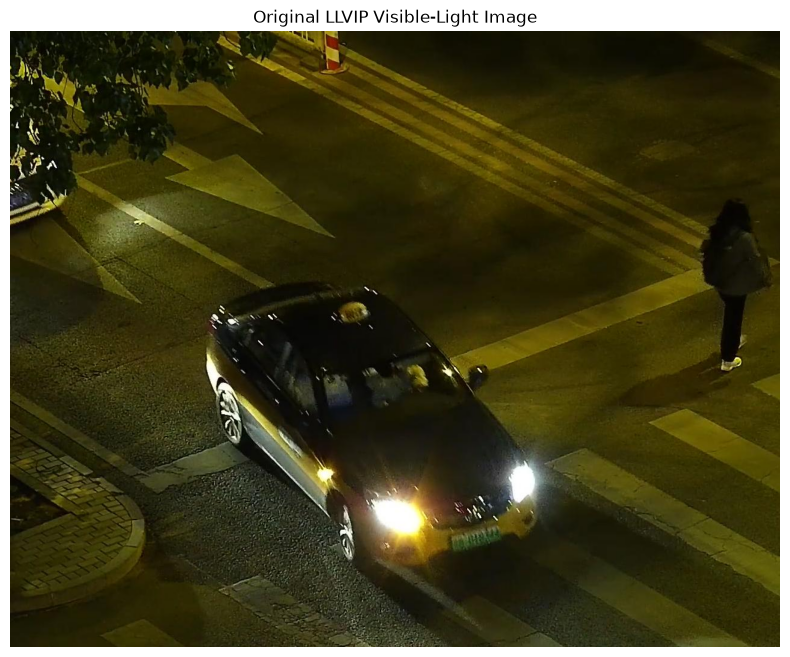

In [22]:
sample_image_path = VISIBLE_ROOT / "test" / "220185.jpg"

sample_image = Image.open(sample_image_path).convert("RGB")

plt.figure(figsize=(12, 8))
plt.imshow(sample_image)
plt.title("Original LLVIP Visible-Light Image")
plt.axis("off")
plt.show()

In [23]:
sys.path.insert(0, str(ZERODCE_CODE))

from model import enhance_net_nopool

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

zerodce_model = enhance_net_nopool().to(DEVICE)

checkpoint = torch.load(
    ZERODCE_WEIGHTS,
    map_location=DEVICE,
    weights_only=False,
)

zerodce_model.load_state_dict(checkpoint)
zerodce_model.eval()

print("Zero-DCE model loaded successfully.")
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Zero-DCE model loaded successfully.
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [24]:
def enhance_with_zerodce(image_path, output_path):
    """
    Enhance one image with Zero-DCE and save it.
    """
    image = Image.open(image_path).convert("RGB")
    original_size = image.size

    image_array = (
        np.asarray(image).astype(np.float32) / 255.0
    )

    tensor = torch.from_numpy(image_array)
    tensor = tensor.permute(2, 0, 1)
    tensor = tensor.unsqueeze(0)
    tensor = tensor.to(DEVICE)

    with torch.no_grad():
        _, enhanced, _ = zerodce_model(tensor)

    enhanced = enhanced.squeeze(0).detach().cpu()
    enhanced = enhanced.permute(1, 2, 0).numpy()
    enhanced = np.clip(
        enhanced * 255.0,
        0,
        255,
    ).astype(np.uint8)

    output = Image.fromarray(enhanced)
    output = output.resize(original_size)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    output.save(output_path, quality=95)

    return output

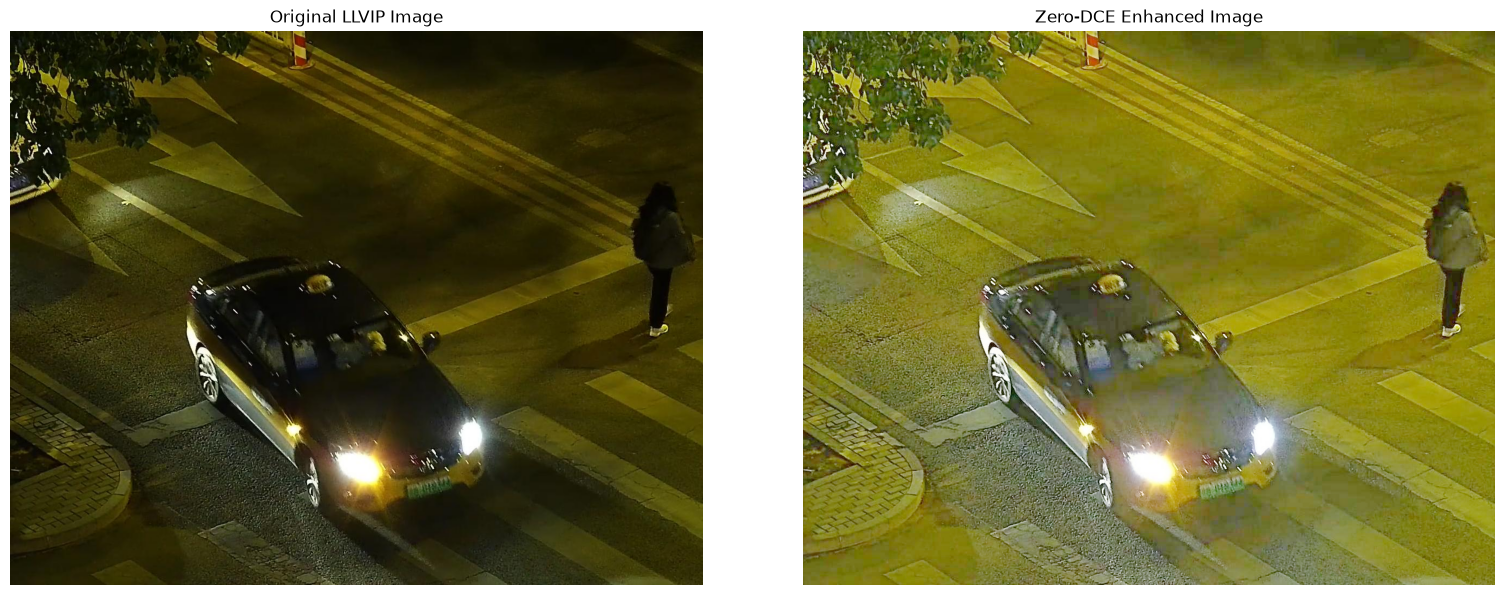

Preview saved to: /home/arjun/lli-pedestrian/data/processed/preview/220185_zerodce.jpg


In [25]:
preview_output = (
    PREVIEW_ROOT / "220185_zerodce.jpg"
)

enhanced_preview = enhance_with_zerodce(
    sample_image_path,
    preview_output,
)

original = Image.open(
    sample_image_path
).convert("RGB")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
)

axes[0].imshow(original)
axes[0].set_title("Original LLVIP Image")
axes[0].axis("off")

axes[1].imshow(enhanced_preview)
axes[1].set_title("Zero-DCE Enhanced Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Preview saved to:", preview_output)

In [26]:
RUN_ENHANCEMENT = True

if RUN_ENHANCEMENT:
    enhancement_start = time.time()

    total_processed = 0
    total_skipped = 0
    total_errors = 0

    for split in ["train", "test"]:
        input_dir = VISIBLE_ROOT / split
        output_dir = PROCESSED_IMAGES_ROOT / split

        output_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        image_paths = sorted(
            input_dir.glob("*.jpg")
        )

        split_processed = 0
        split_skipped = 0
        split_errors = 0

        print(
            f"\nStarting Zero-DCE enhancement for {split}: "
            f"{len(image_paths)} images"
        )

        for index, image_path in enumerate(
            image_paths,
            start=1,
        ):
            output_path = output_dir / image_path.name

            # Skip files already completed.
            if output_path.exists():
                split_skipped += 1
                total_skipped += 1
            else:
                try:
                    enhance_with_zerodce(
                        image_path,
                        output_path,
                    )

                    split_processed += 1
                    total_processed += 1

                except Exception as error:
                    split_errors += 1
                    total_errors += 1

                    print(
                        f"\nError processing "
                        f"{image_path.name}: {error}"
                    )

            # Plain text progress update.
            if index == 1 or index % 500 == 0 or index == len(image_paths):
                print(
                    f"{split}: {index}/{len(image_paths)} | "
                    f"new={split_processed}, "
                    f"skipped={split_skipped}, "
                    f"errors={split_errors}"
                )

        print(
            f"Finished {split}: "
            f"new={split_processed}, "
            f"skipped={split_skipped}, "
            f"errors={split_errors}"
        )

    elapsed_minutes = (
        time.time() - enhancement_start
    ) / 60

    print("\nEnhancement complete.")
    print(f"New images processed: {total_processed}")
    print(f"Existing images skipped: {total_skipped}")
    print(f"Errors: {total_errors}")
    print(f"Elapsed time: {elapsed_minutes:.2f} minutes")

else:
    print("Enhancement skipped.")


Starting Zero-DCE enhancement for train: 12025 images
train: 1/12025 | new=0, skipped=1, errors=0
train: 500/12025 | new=0, skipped=500, errors=0
train: 1000/12025 | new=0, skipped=1000, errors=0
train: 1500/12025 | new=0, skipped=1500, errors=0
train: 2000/12025 | new=0, skipped=2000, errors=0
train: 2500/12025 | new=0, skipped=2500, errors=0
train: 3000/12025 | new=0, skipped=3000, errors=0
train: 3500/12025 | new=0, skipped=3500, errors=0
train: 4000/12025 | new=0, skipped=4000, errors=0
train: 4500/12025 | new=0, skipped=4500, errors=0
train: 5000/12025 | new=0, skipped=5000, errors=0
train: 5500/12025 | new=0, skipped=5500, errors=0
train: 6000/12025 | new=0, skipped=6000, errors=0
train: 6500/12025 | new=0, skipped=6500, errors=0
train: 7000/12025 | new=0, skipped=7000, errors=0
train: 7500/12025 | new=0, skipped=7500, errors=0
train: 8000/12025 | new=0, skipped=8000, errors=0
train: 8500/12025 | new=0, skipped=8500, errors=0
train: 9000/12025 | new=0, skipped=9000, errors=0
tra

In [27]:
enhanced_train = sorted(
    (PROCESSED_IMAGES_ROOT / "train").glob("*.jpg")
)

enhanced_test = sorted(
    (PROCESSED_IMAGES_ROOT / "test").glob("*.jpg")
)

print("Enhanced training images:", len(enhanced_train))
print("Enhanced test images:", len(enhanced_test))
print("Total enhanced images:", len(enhanced_train) + len(enhanced_test))

assert len(enhanced_train) == 12025
assert len(enhanced_test) == 3463

print("Enhanced dataset verification passed.")

Enhanced training images: 12025
Enhanced test images: 3463
Total enhanced images: 15488
Enhanced dataset verification passed.


In [28]:
def get_image_size(image_path):
    with Image.open(image_path) as image:
        return image.width, image.height


def convert_xml_to_yolo(
    xml_path,
    image_width,
    image_height,
):
    """
    Convert Pascal VOC XML boxes to YOLO format.

    YOLO format:
    class_id center_x center_y width height

    All coordinates are normalized from 0 to 1.
    """

    tree = ET.parse(xml_path)
    root = tree.getroot()

    yolo_lines = []

    for obj in root.findall("object"):
        class_name = obj.findtext(
            "name",
            "",
        ).strip().lower()

        if class_name != "person":
            continue

        box = obj.find("bndbox")

        if box is None:
            continue

        xmin = float(box.findtext("xmin"))
        ymin = float(box.findtext("ymin"))
        xmax = float(box.findtext("xmax"))
        ymax = float(box.findtext("ymax"))

        center_x = (
            (xmin + xmax) / 2
        ) / image_width

        center_y = (
            (ymin + ymax) / 2
        ) / image_height

        box_width = (
            xmax - xmin
        ) / image_width

        box_height = (
            ymax - ymin
        ) / image_height

        values = [
            0,
            max(0.0, min(1.0, center_x)),
            max(0.0, min(1.0, center_y)),
            max(0.0, min(1.0, box_width)),
            max(0.0, min(1.0, box_height)),
        ]

        yolo_lines.append(
            f"{int(values[0])} "
            f"{values[1]:.6f} "
            f"{values[2]:.6f} "
            f"{values[3]:.6f} "
            f"{values[4]:.6f}\n"
        )

    return yolo_lines

In [29]:
RUN_LABEL_CONVERSION = True

if RUN_LABEL_CONVERSION:
    conversion_start = time.time()

    for split in ["train", "test"]:
        image_dir = VISIBLE_ROOT / split
        output_dir = PROCESSED_LABELS_ROOT / split

        output_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        image_paths = sorted(
            image_dir.glob("*.jpg")
        )

        for image_path in tqdm(
            image_paths,
            desc=f"Converting {split} labels",
        ):
            xml_path = (
                ANNOTATIONS_ROOT
                / f"{image_path.stem}.xml"
            )

            output_path = (
                output_dir
                / f"{image_path.stem}.txt"
            )

            width, height = get_image_size(
                image_path
            )

            yolo_lines = convert_xml_to_yolo(
                xml_path,
                width,
                height,
            )

            output_path.write_text(
                "".join(yolo_lines)
            )

    elapsed_seconds = time.time() - conversion_start

    print(
        f"Annotation conversion complete in "
        f"{elapsed_seconds:.2f} seconds."
    )

else:
    print("Annotation conversion skipped.")

Converting train labels:   0%|          | 0/12025 [00:00<?, ?it/s]

Converting test labels:   0%|          | 0/3463 [00:00<?, ?it/s]

Annotation conversion complete in 12.49 seconds.


In [30]:
sample_label_path = (
    PROCESSED_LABELS_ROOT
    / "test"
    / "220185.txt"
)

print(sample_label_path.read_text())

0 0.939453 0.412109 0.094531 0.312500



In [31]:
RUN_DATASET_SPLIT = True
VALIDATION_RATIO = 0.20
RANDOM_SEED = 42

if RUN_DATASET_SPLIT:
    for split in ["train", "val", "test"]:
        (
            YOLO_ROOT
            / "images"
            / split
        ).mkdir(
            parents=True,
            exist_ok=True,
        )

        (
            YOLO_ROOT
            / "labels"
            / split
        ).mkdir(
            parents=True,
            exist_ok=True,
        )

    print("YOLO folders created.")
else:
    print("Dataset folder creation skipped.")

YOLO folders created.


In [32]:
if RUN_DATASET_SPLIT:
    random.seed(RANDOM_SEED)

    source_train_images = sorted(
        (
            PROCESSED_IMAGES_ROOT
            / "train"
        ).glob("*.jpg")
    )

    random.shuffle(source_train_images)

    validation_count = int(
        len(source_train_images)
        * VALIDATION_RATIO
    )

    validation_images = (
        source_train_images[:validation_count]
    )

    training_images = (
        source_train_images[validation_count:]
    )

    def copy_image_label_pair(
        image_path,
        label_source_dir,
        output_split,
    ):
        label_path = (
            label_source_dir
            / f"{image_path.stem}.txt"
        )

        if not label_path.exists():
            raise FileNotFoundError(
                f"Missing label: {label_path}"
            )

        output_image = (
            YOLO_ROOT
            / "images"
            / output_split
            / image_path.name
        )

        output_label = (
            YOLO_ROOT
            / "labels"
            / output_split
            / label_path.name
        )

        shutil.copy2(
            image_path,
            output_image,
        )

        shutil.copy2(
            label_path,
            output_label,
        )

    for image_path in tqdm(
        training_images,
        desc="Copying training set",
    ):
        copy_image_label_pair(
            image_path,
            PROCESSED_LABELS_ROOT / "train",
            "train",
        )

    for image_path in tqdm(
        validation_images,
        desc="Copying validation set",
    ):
        copy_image_label_pair(
            image_path,
            PROCESSED_LABELS_ROOT / "train",
            "val",
        )

    source_test_images = sorted(
        (
            PROCESSED_IMAGES_ROOT
            / "test"
        ).glob("*.jpg")
    )

    for image_path in tqdm(
        source_test_images,
        desc="Copying test set",
    ):
        copy_image_label_pair(
            image_path,
            PROCESSED_LABELS_ROOT / "test",
            "test",
        )

    print("Dataset split complete.")
    print("Training images:", len(training_images))
    print("Validation images:", len(validation_images))
    print("Test images:", len(source_test_images))

else:
    print("Dataset split skipped.")

Copying training set:   0%|          | 0/9620 [00:00<?, ?it/s]

Copying validation set:   0%|          | 0/2405 [00:00<?, ?it/s]

Copying test set:   0%|          | 0/3463 [00:00<?, ?it/s]

Dataset split complete.
Training images: 9620
Validation images: 2405
Test images: 3463


In [33]:
data_yaml = f"""path: {YOLO_ROOT}

train: images/train
val: images/val
test: images/test

names:
  0: person
"""

data_yaml_path = YOLO_ROOT / "data.yaml"
data_yaml_path.write_text(data_yaml)

print(data_yaml_path.read_text())

path: /home/arjun/lli-pedestrian/data/yolo

train: images/train
val: images/val
test: images/test

names:
  0: person



In [34]:
dataset_counts = {}

for split in ["train", "val", "test"]:
    image_count = len(
        list(
            (
                YOLO_ROOT
                / "images"
                / split
            ).glob("*.jpg")
        )
    )

    label_count = len(
        list(
            (
                YOLO_ROOT
                / "labels"
                / split
            ).glob("*.txt")
        )
    )

    dataset_counts[split] = {
        "images": image_count,
        "labels": label_count,
    }

    print(
        f"{split}: "
        f"images={image_count}, "
        f"labels={label_count}"
    )

assert dataset_counts["train"]["images"] == 9620
assert dataset_counts["train"]["labels"] == 9620

assert dataset_counts["val"]["images"] == 2405
assert dataset_counts["val"]["labels"] == 2405

assert dataset_counts["test"]["images"] == 3463
assert dataset_counts["test"]["labels"] == 3463

print("\nYOLO dataset verification passed.")

train: images=9620, labels=9620
val: images=2405, labels=2405
test: images=3463, labels=3463

YOLO dataset verification passed.


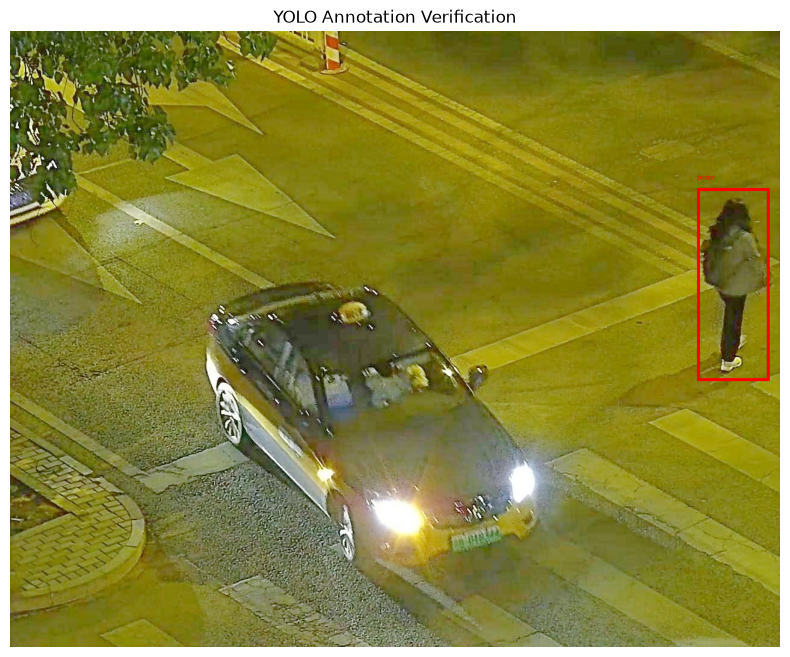

In [35]:
sample_yolo_image = (
    YOLO_ROOT
    / "images"
    / "test"
    / "220185.jpg"
)

sample_yolo_label = (
    YOLO_ROOT
    / "labels"
    / "test"
    / "220185.txt"
)

image = Image.open(
    sample_yolo_image
).convert("RGB")

draw = ImageDraw.Draw(image)

image_width, image_height = image.size

for line in sample_yolo_label.read_text().splitlines():
    values = line.split()

    if len(values) != 5:
        continue

    class_id, center_x, center_y, box_width, box_height = map(
        float,
        values,
    )

    center_x *= image_width
    center_y *= image_height
    box_width *= image_width
    box_height *= image_height

    xmin = center_x - box_width / 2
    ymin = center_y - box_height / 2
    xmax = center_x + box_width / 2
    ymax = center_y + box_height / 2

    draw.rectangle(
        [xmin, ymin, xmax, ymax],
        outline="red",
        width=5,
    )

    draw.text(
        [xmin, max(0, ymin - 25)],
        "person",
        fill="red",
    )

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.title("YOLO Annotation Verification")
plt.axis("off")
plt.show()

In [36]:
from ultralytics import YOLO

RUN_TRAINING = False

TRAINING_NAME = "pedestrian_zerodce_yolov8n_notebook"

if RUN_TRAINING:
    model = YOLO("yolov8n.pt")

    training_results = model.train(
        data=str(data_yaml_path),
        epochs=50,
        imgsz=640,
        batch=4,
        device=0,
        workers=0,
        project=str(RUNS_ROOT),
        name=TRAINING_NAME,
        exist_ok=True,
        pretrained=True,
        patience=15,
        plots=True,
        save=True,
        seed=0,
        verbose=True,
    )

    print("Training complete.")

else:
    model_path = (
        RUNS_ROOT
        / TRAINING_NAME
        / "weights"
        / "best.pt"
    )

    model = YOLO(str(model_path))
    print("Existing model loaded:", model_path)

Existing model loaded: /home/arjun/lli-pedestrian/runs/pedestrian_zerodce_yolov8n_notebook/weights/best.pt


In [37]:
TRAINING_ROOT = RUNS_ROOT / TRAINING_NAME
BEST_MODEL_PATH = (
    TRAINING_ROOT
    / "weights"
    / "best.pt"
)

LAST_MODEL_PATH = (
    TRAINING_ROOT
    / "weights"
    / "last.pt"
)

print("Training directory:", TRAINING_ROOT)
print("Best model exists:", BEST_MODEL_PATH.exists())
print("Last model exists:", LAST_MODEL_PATH.exists())

Training directory: /home/arjun/lli-pedestrian/runs/pedestrian_zerodce_yolov8n_notebook
Best model exists: True
Last model exists: True


In [38]:
results_csv_path = TRAINING_ROOT / "results.csv"

results_df = pd.read_csv(results_csv_path)

display(results_df.tail())

print("Best model:", BEST_MODEL_PATH)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
45,46,10491.2,1.38880,0.71402,1.20936,0.92353,0.87701,0.93336,0.53305,1.49830,0.71333,1.24962,0.000218,0.000218,0.000218
46,47,10708.3,1.37924,0.71361,1.20373,0.92797,0.87627,0.93410,0.53437,1.49870,0.71385,1.24911,0.000178,0.000178,0.000178
47,48,10923.3,1.37751,0.70652,1.20291,0.92856,0.87388,0.93342,0.53554,1.49393,0.71103,1.24754,0.000139,0.000139,0.000139
48,49,11140.5,1.37007,0.70168,1.19921,0.92535,0.87411,0.93296,0.53577,1.49288,0.71283,1.24647,0.000099,0.000099,0.000099
49,50,11353.8,1.36964,0.70037,1.19869,0.92632,0.87657,0.93339,0.53577,1.49280,0.70882,1.24565,0.000060,0.000060,0.000060


Best model: /home/arjun/lli-pedestrian/runs/pedestrian_zerodce_yolov8n_notebook/weights/best.pt


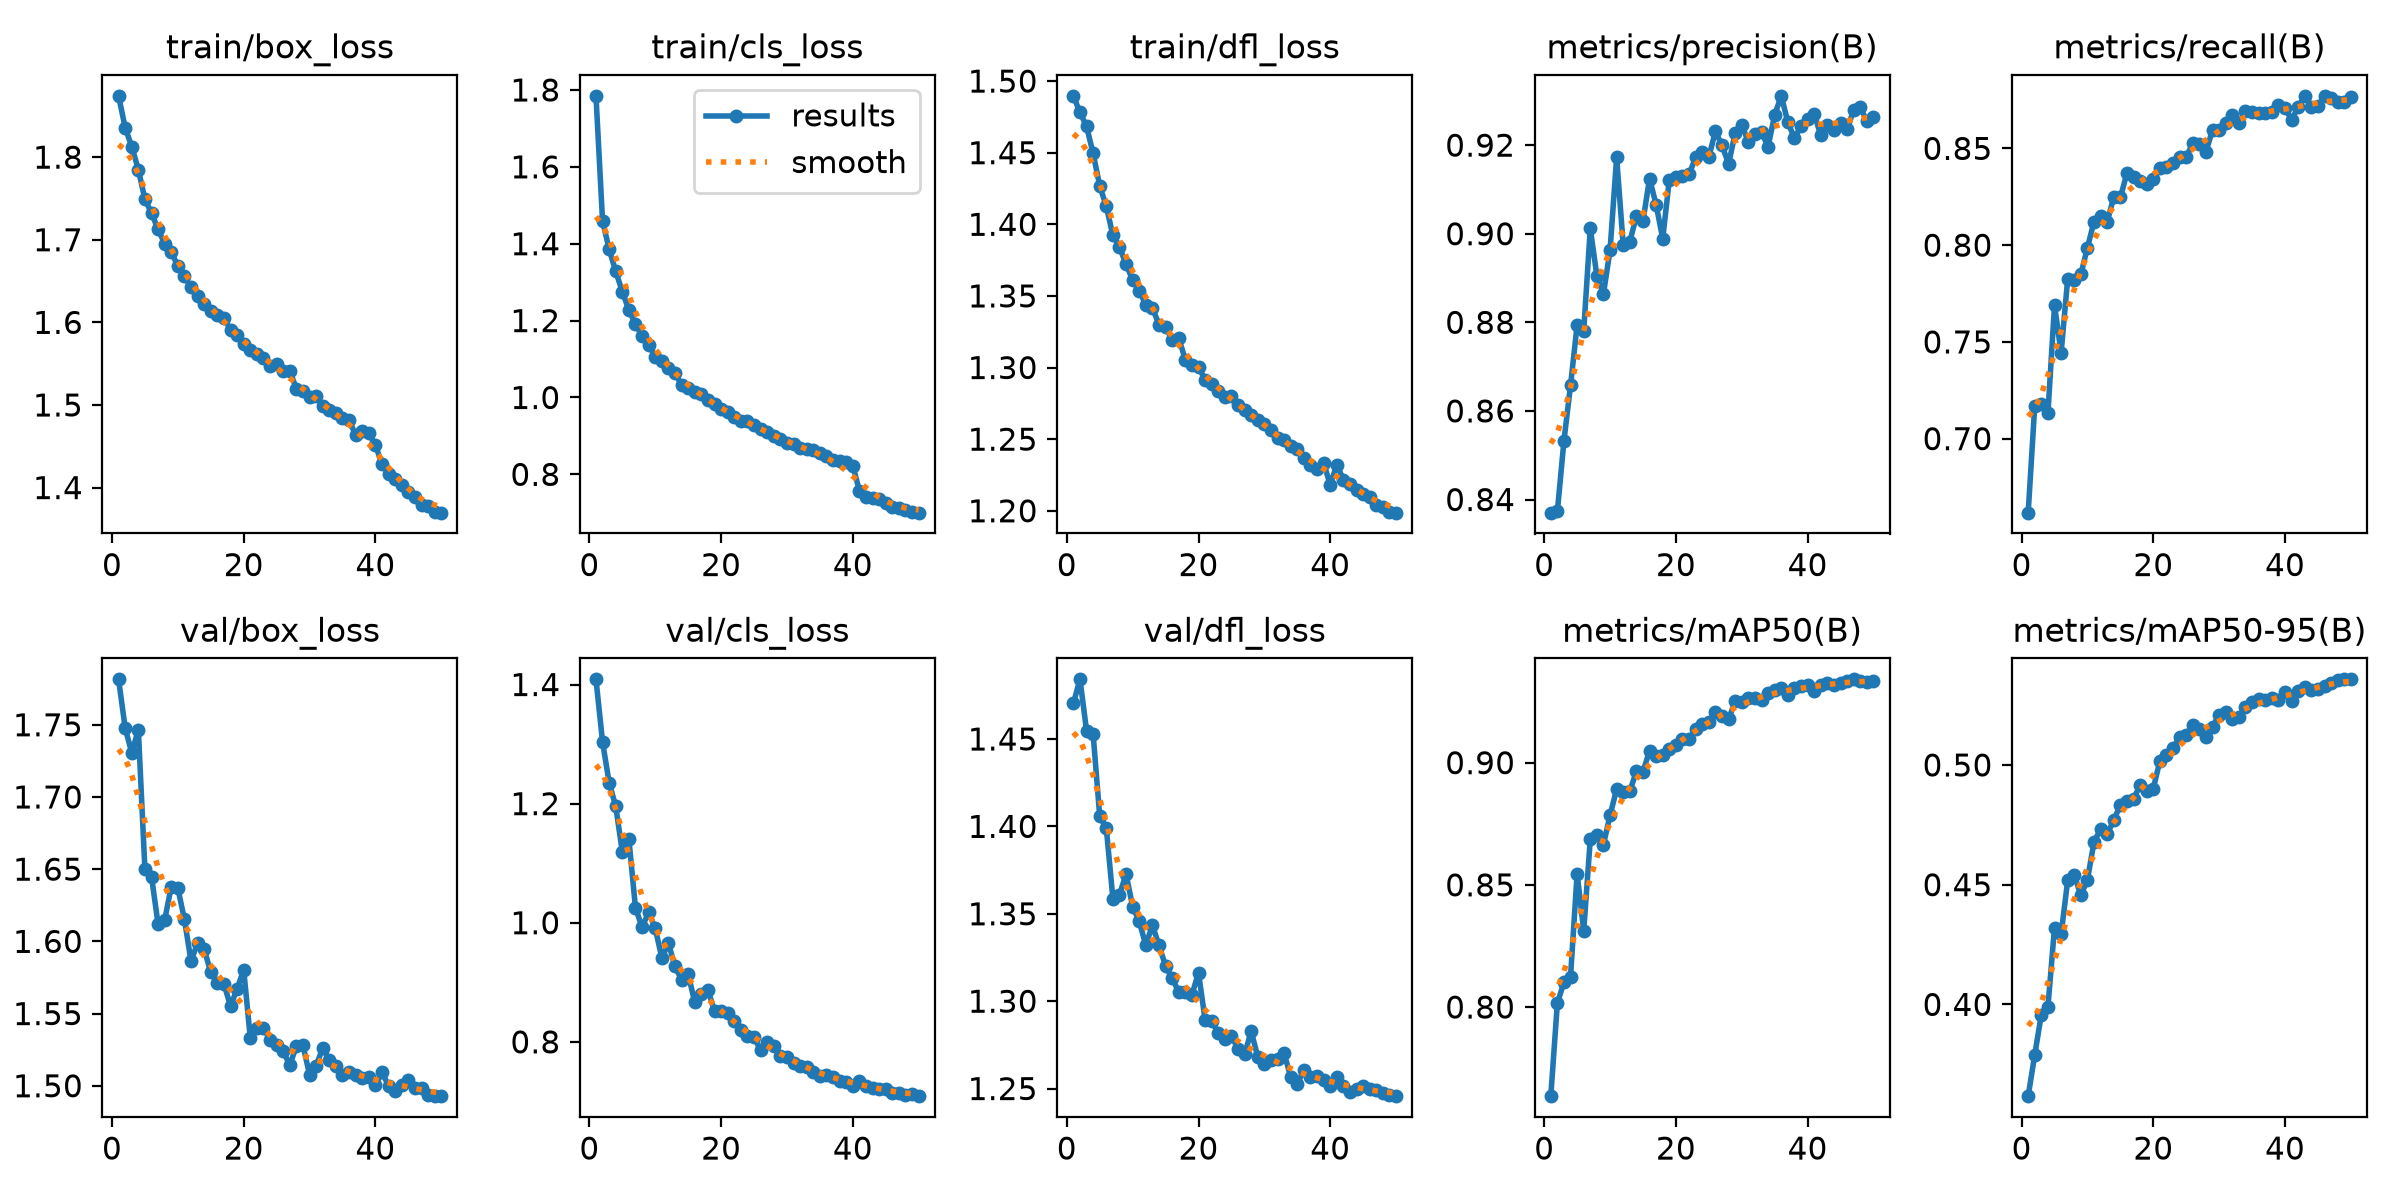

In [39]:
training_plot_path = TRAINING_ROOT / "results.png"

if training_plot_path.exists():
    display(
        IPImage(
            filename=str(training_plot_path)
        )
    )
else:
    print("Training plot not found:", training_plot_path)

confusion_matrix.png exists: True


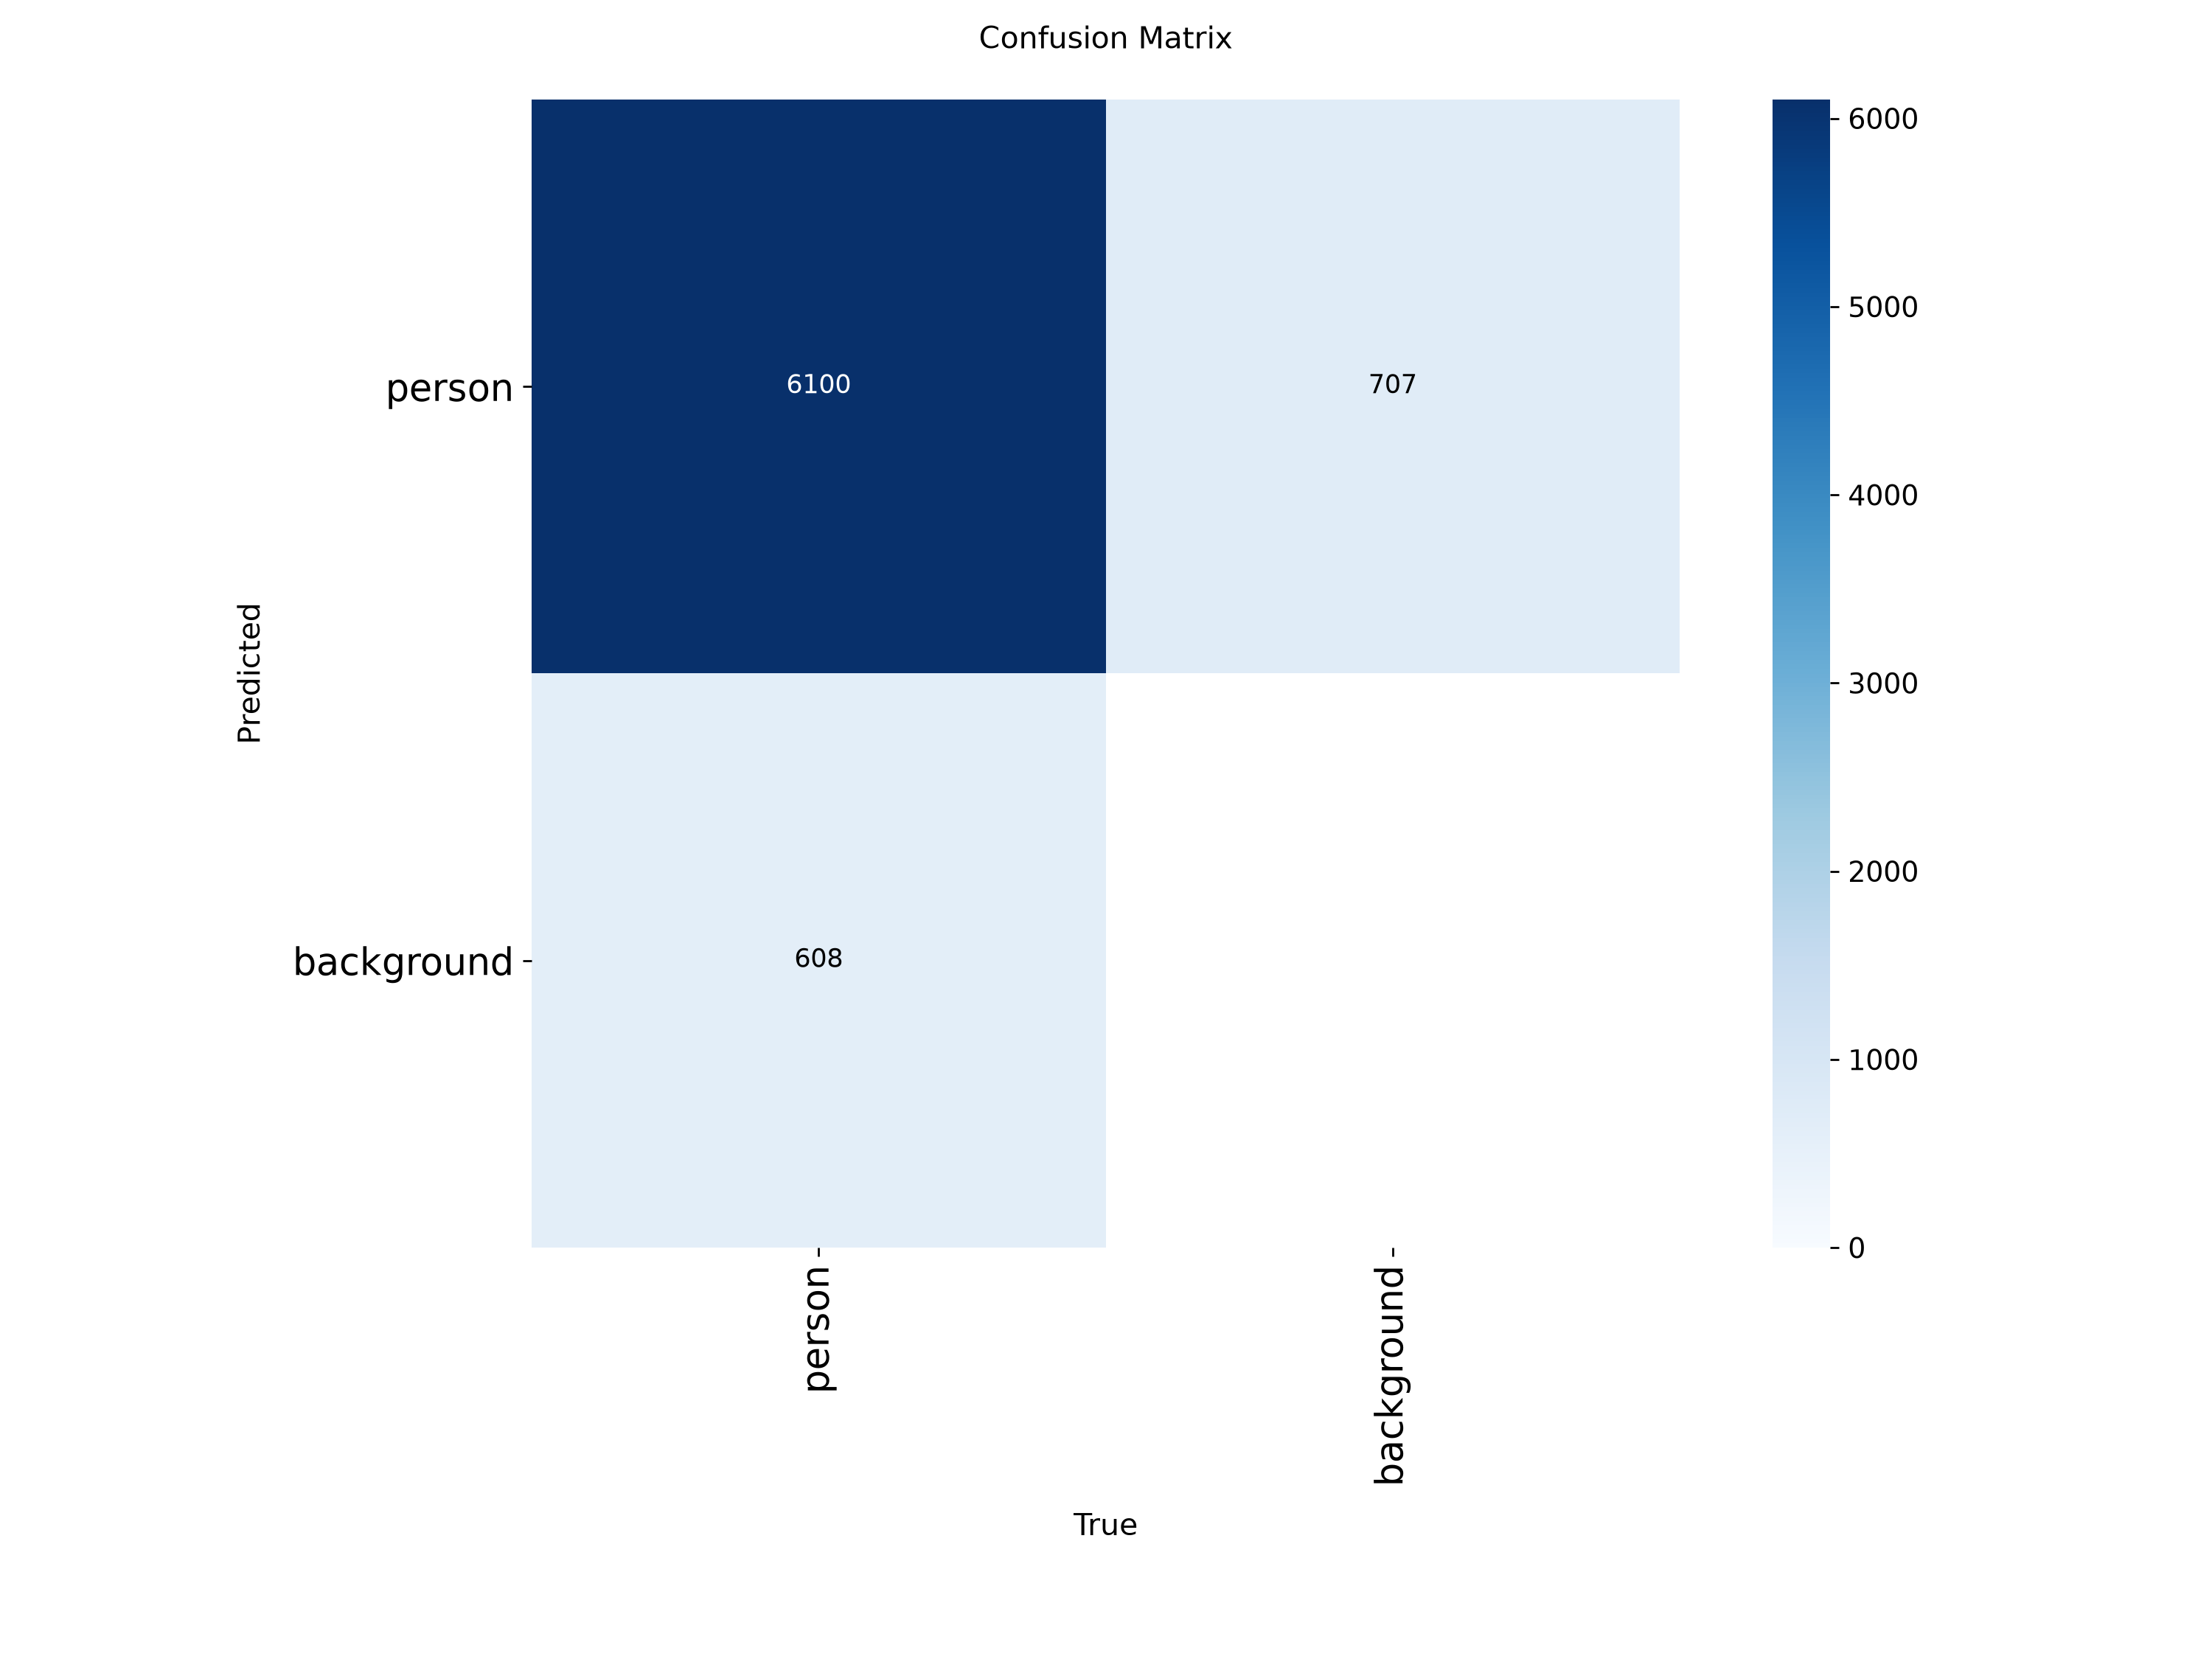

confusion_matrix_normalized.png exists: True


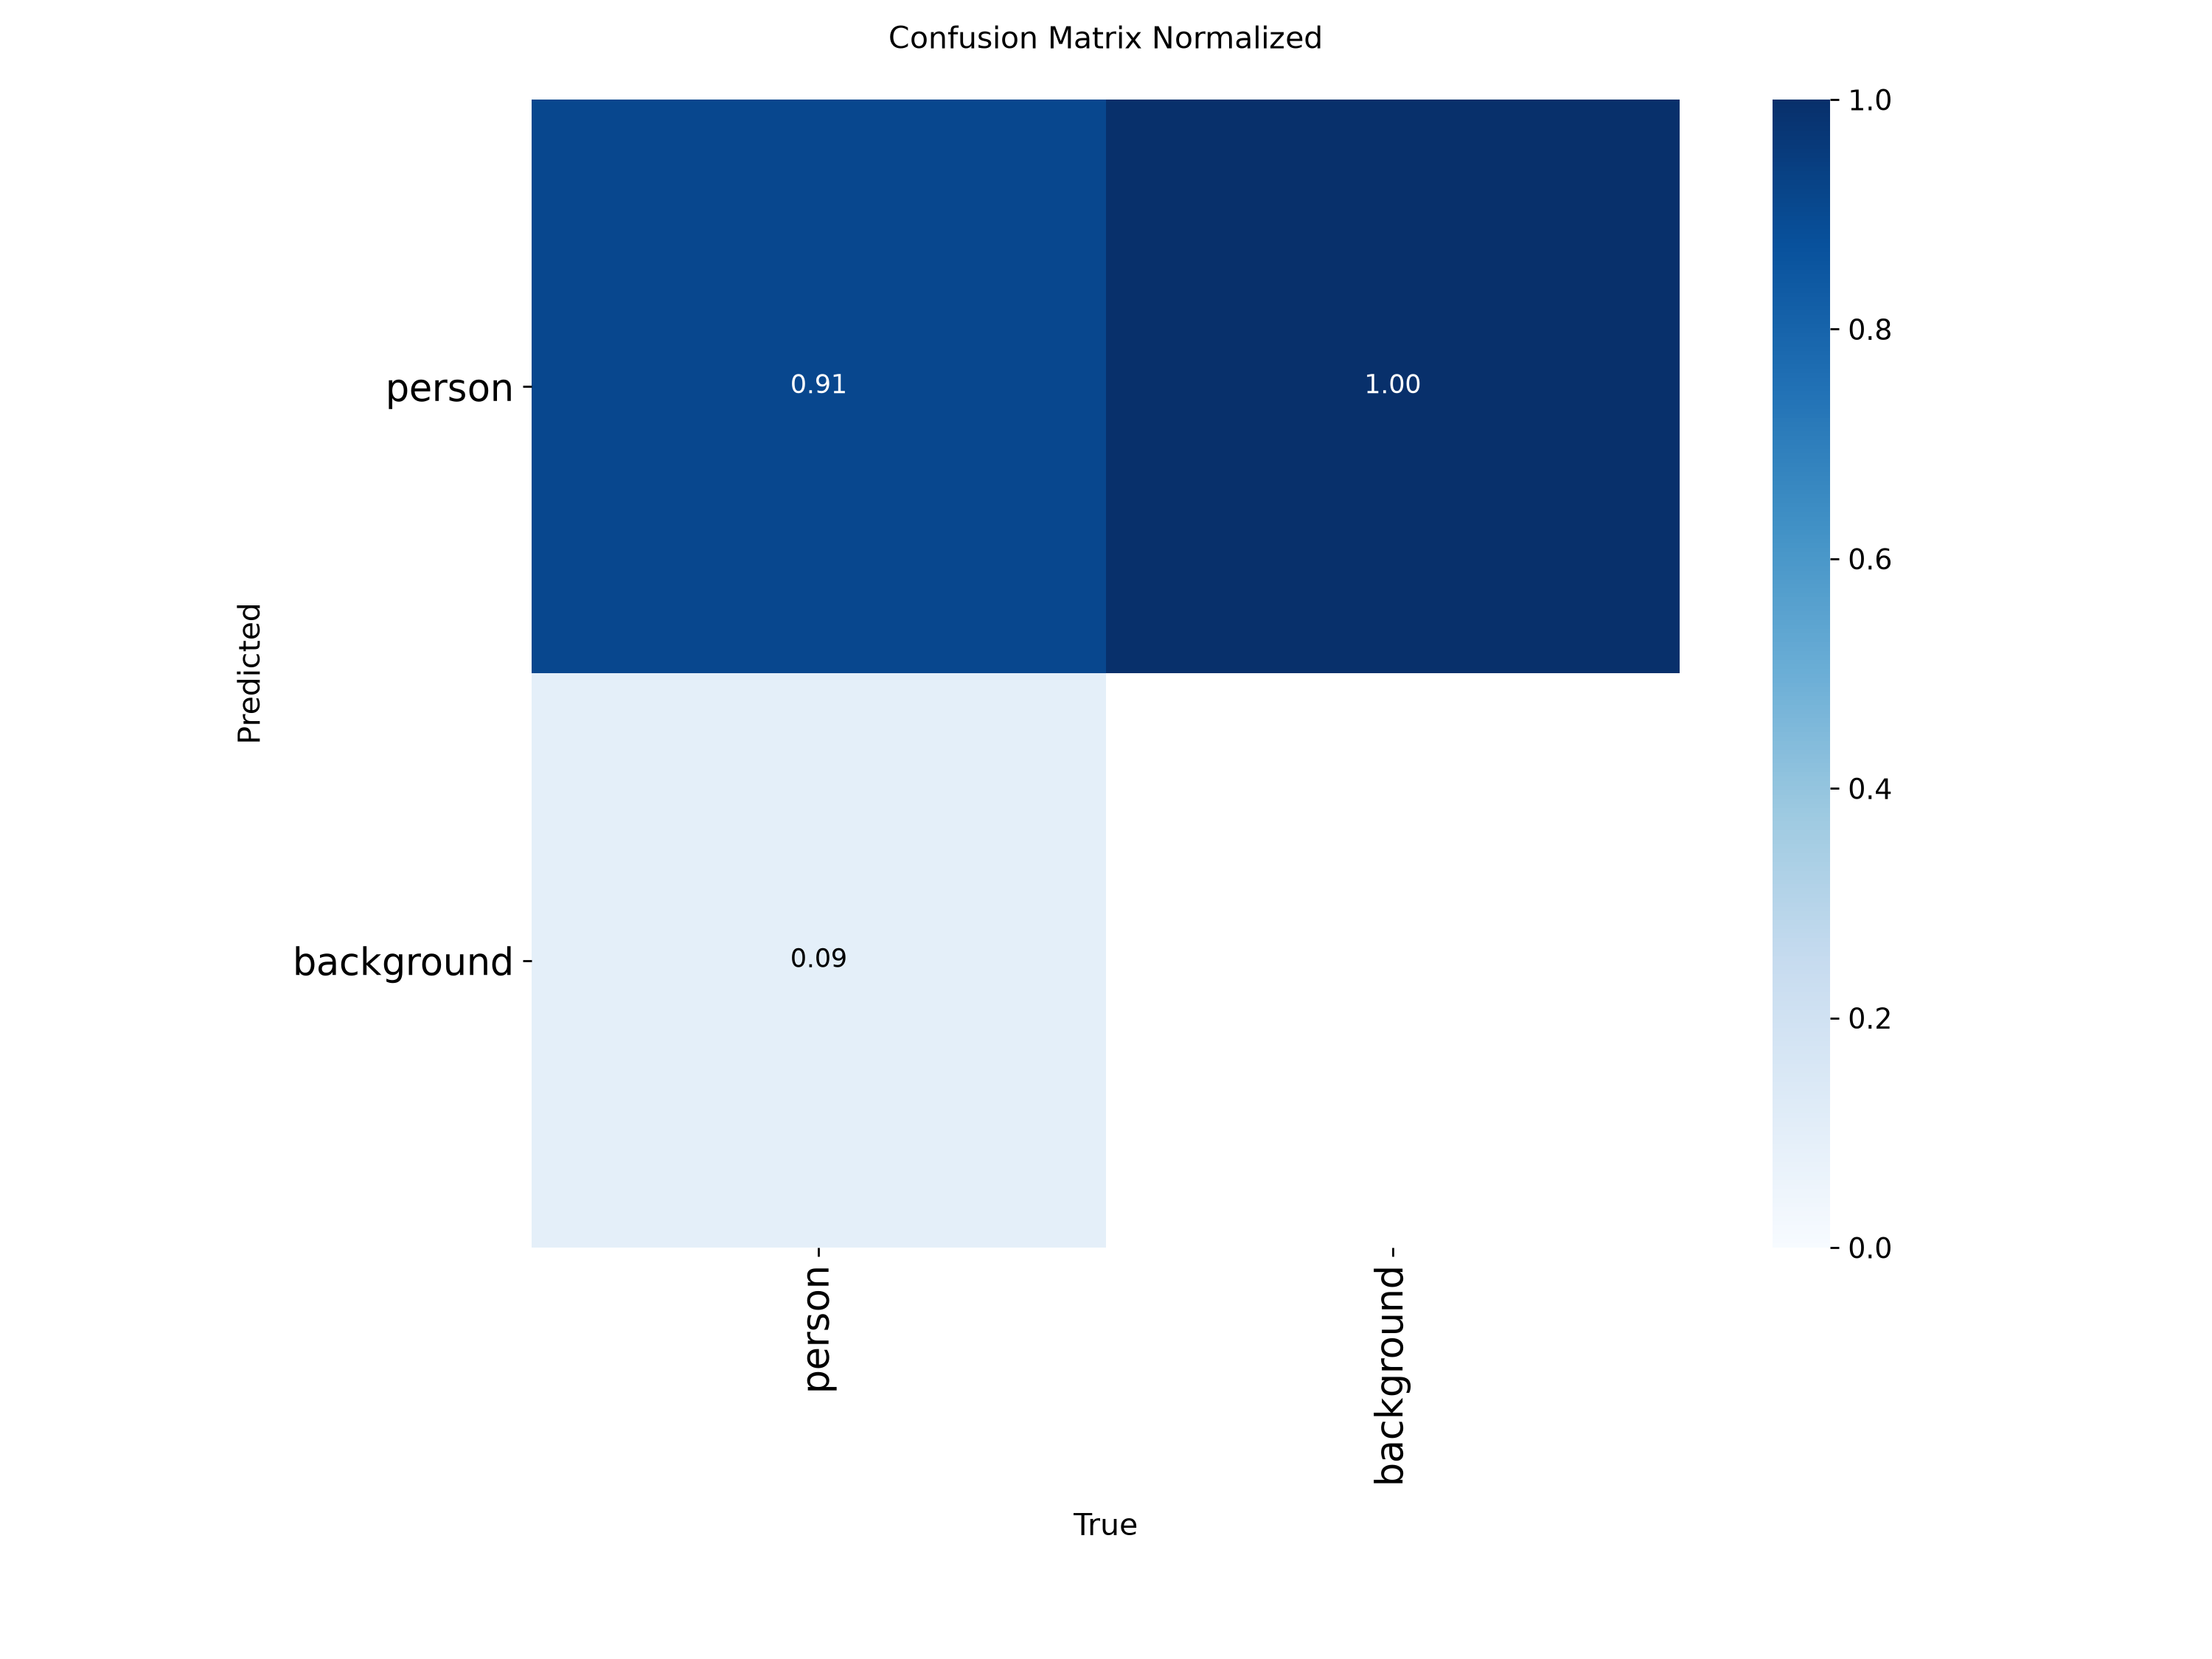

BoxPR_curve.png exists: True


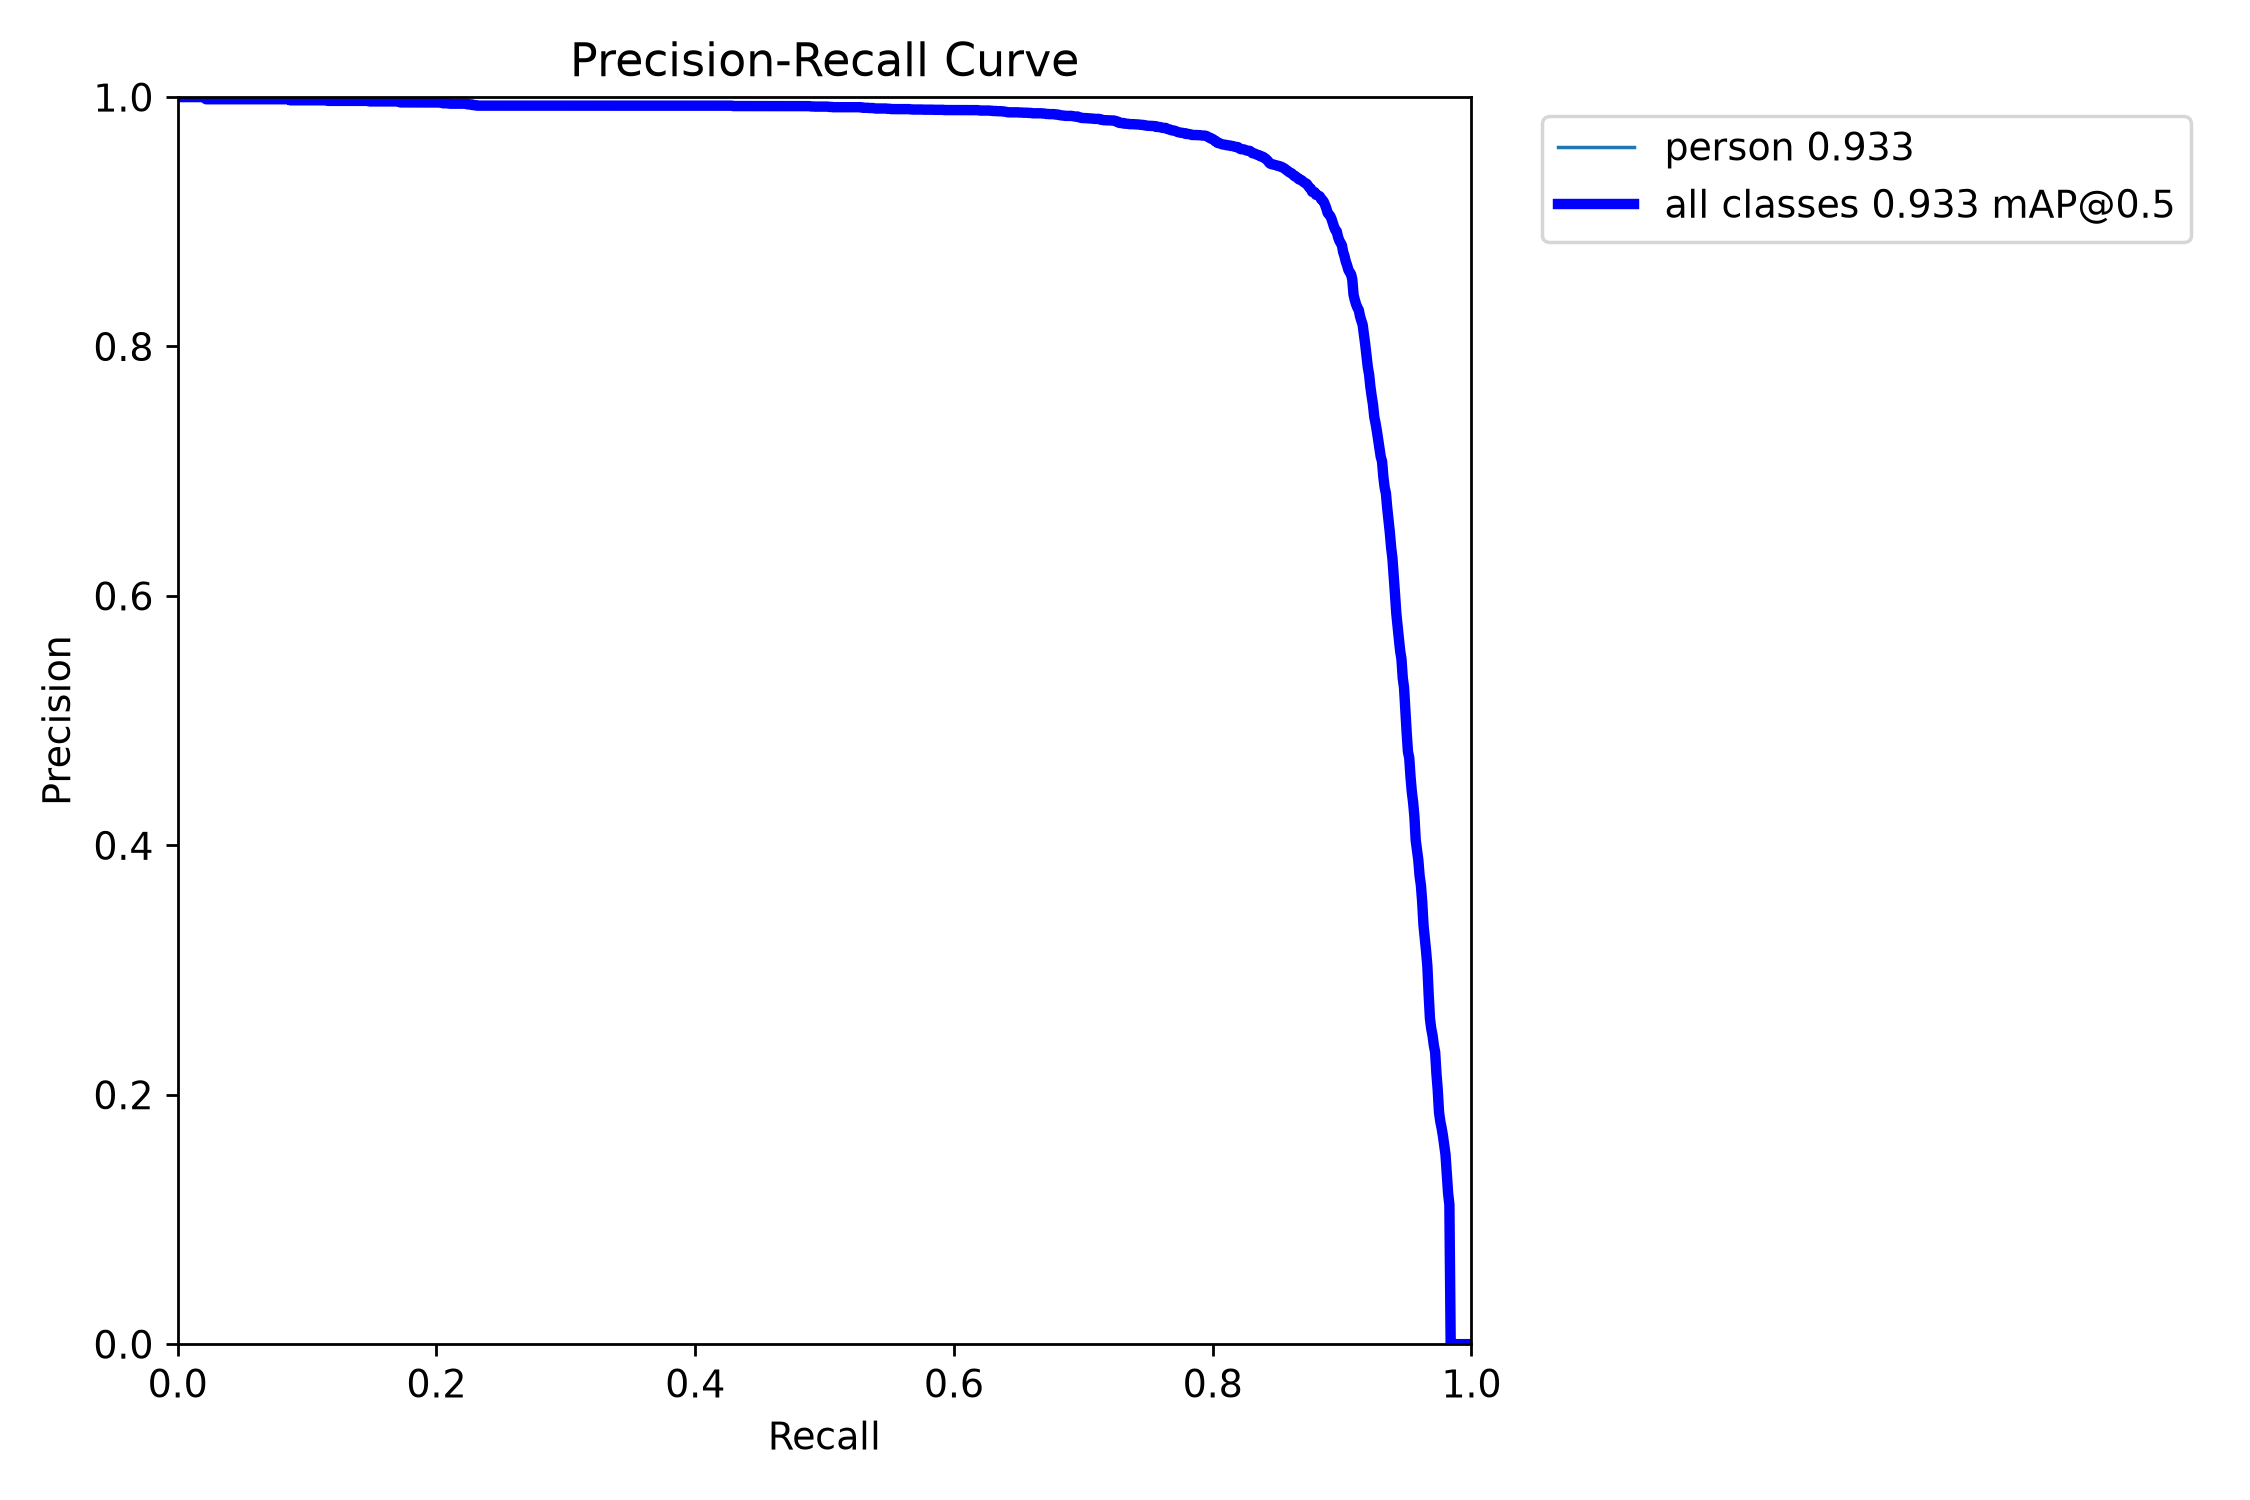

BoxF1_curve.png exists: True


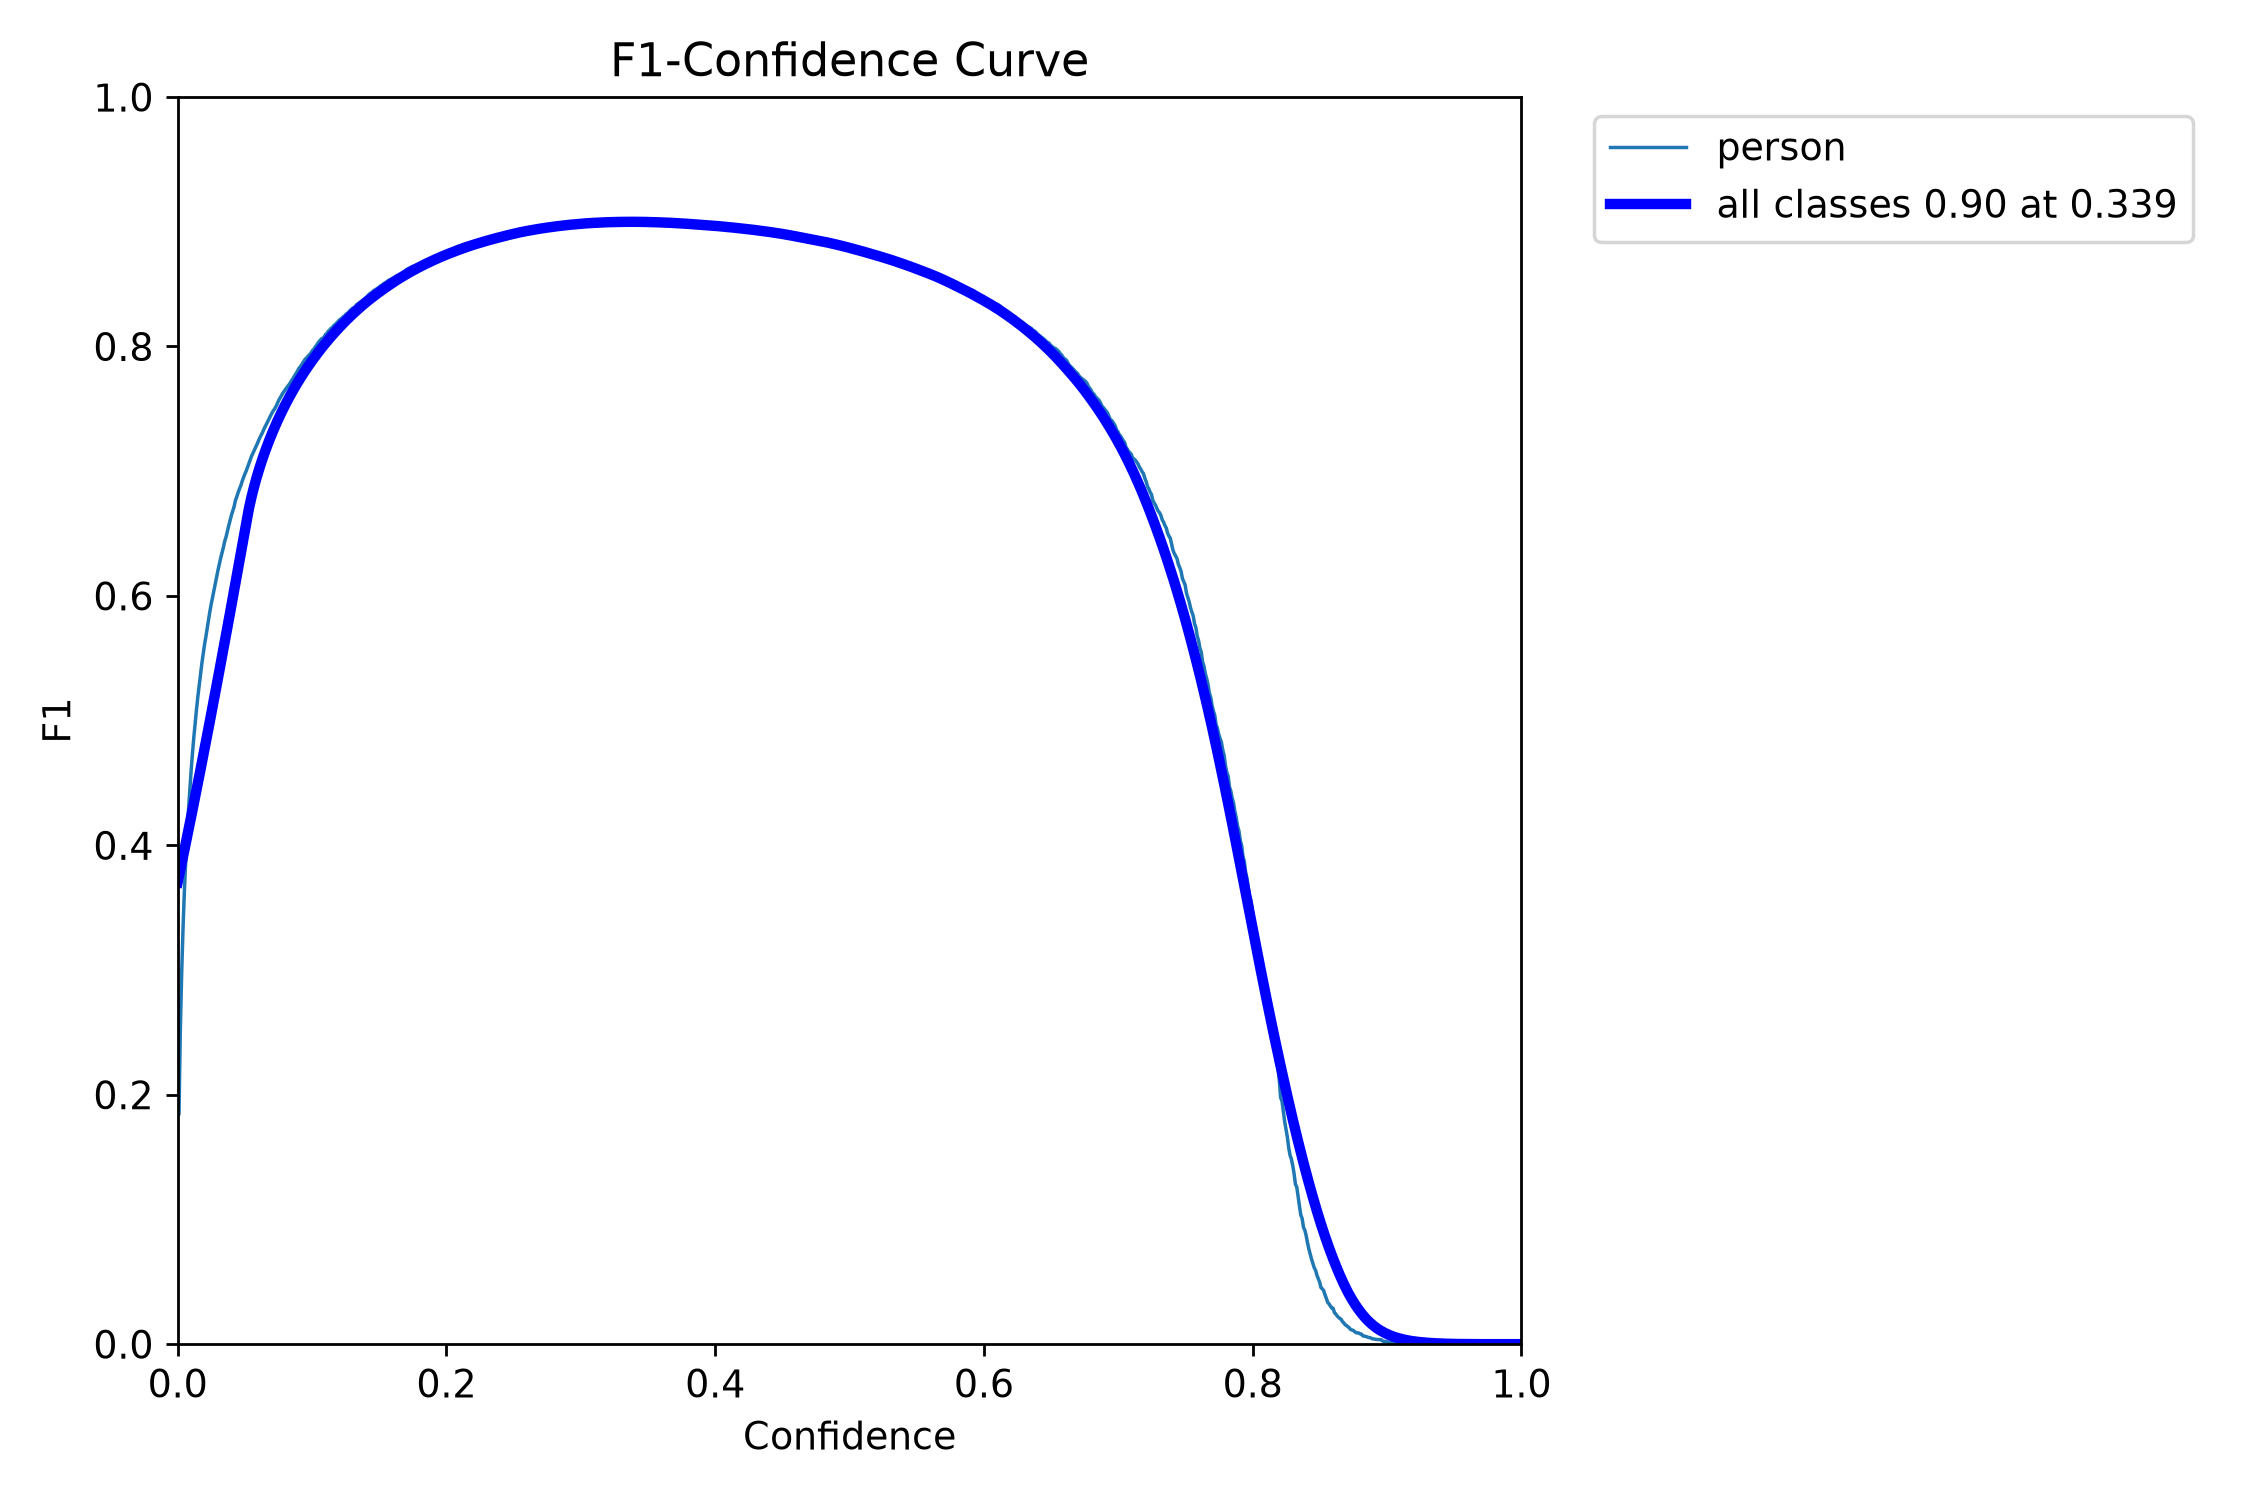

BoxP_curve.png exists: True


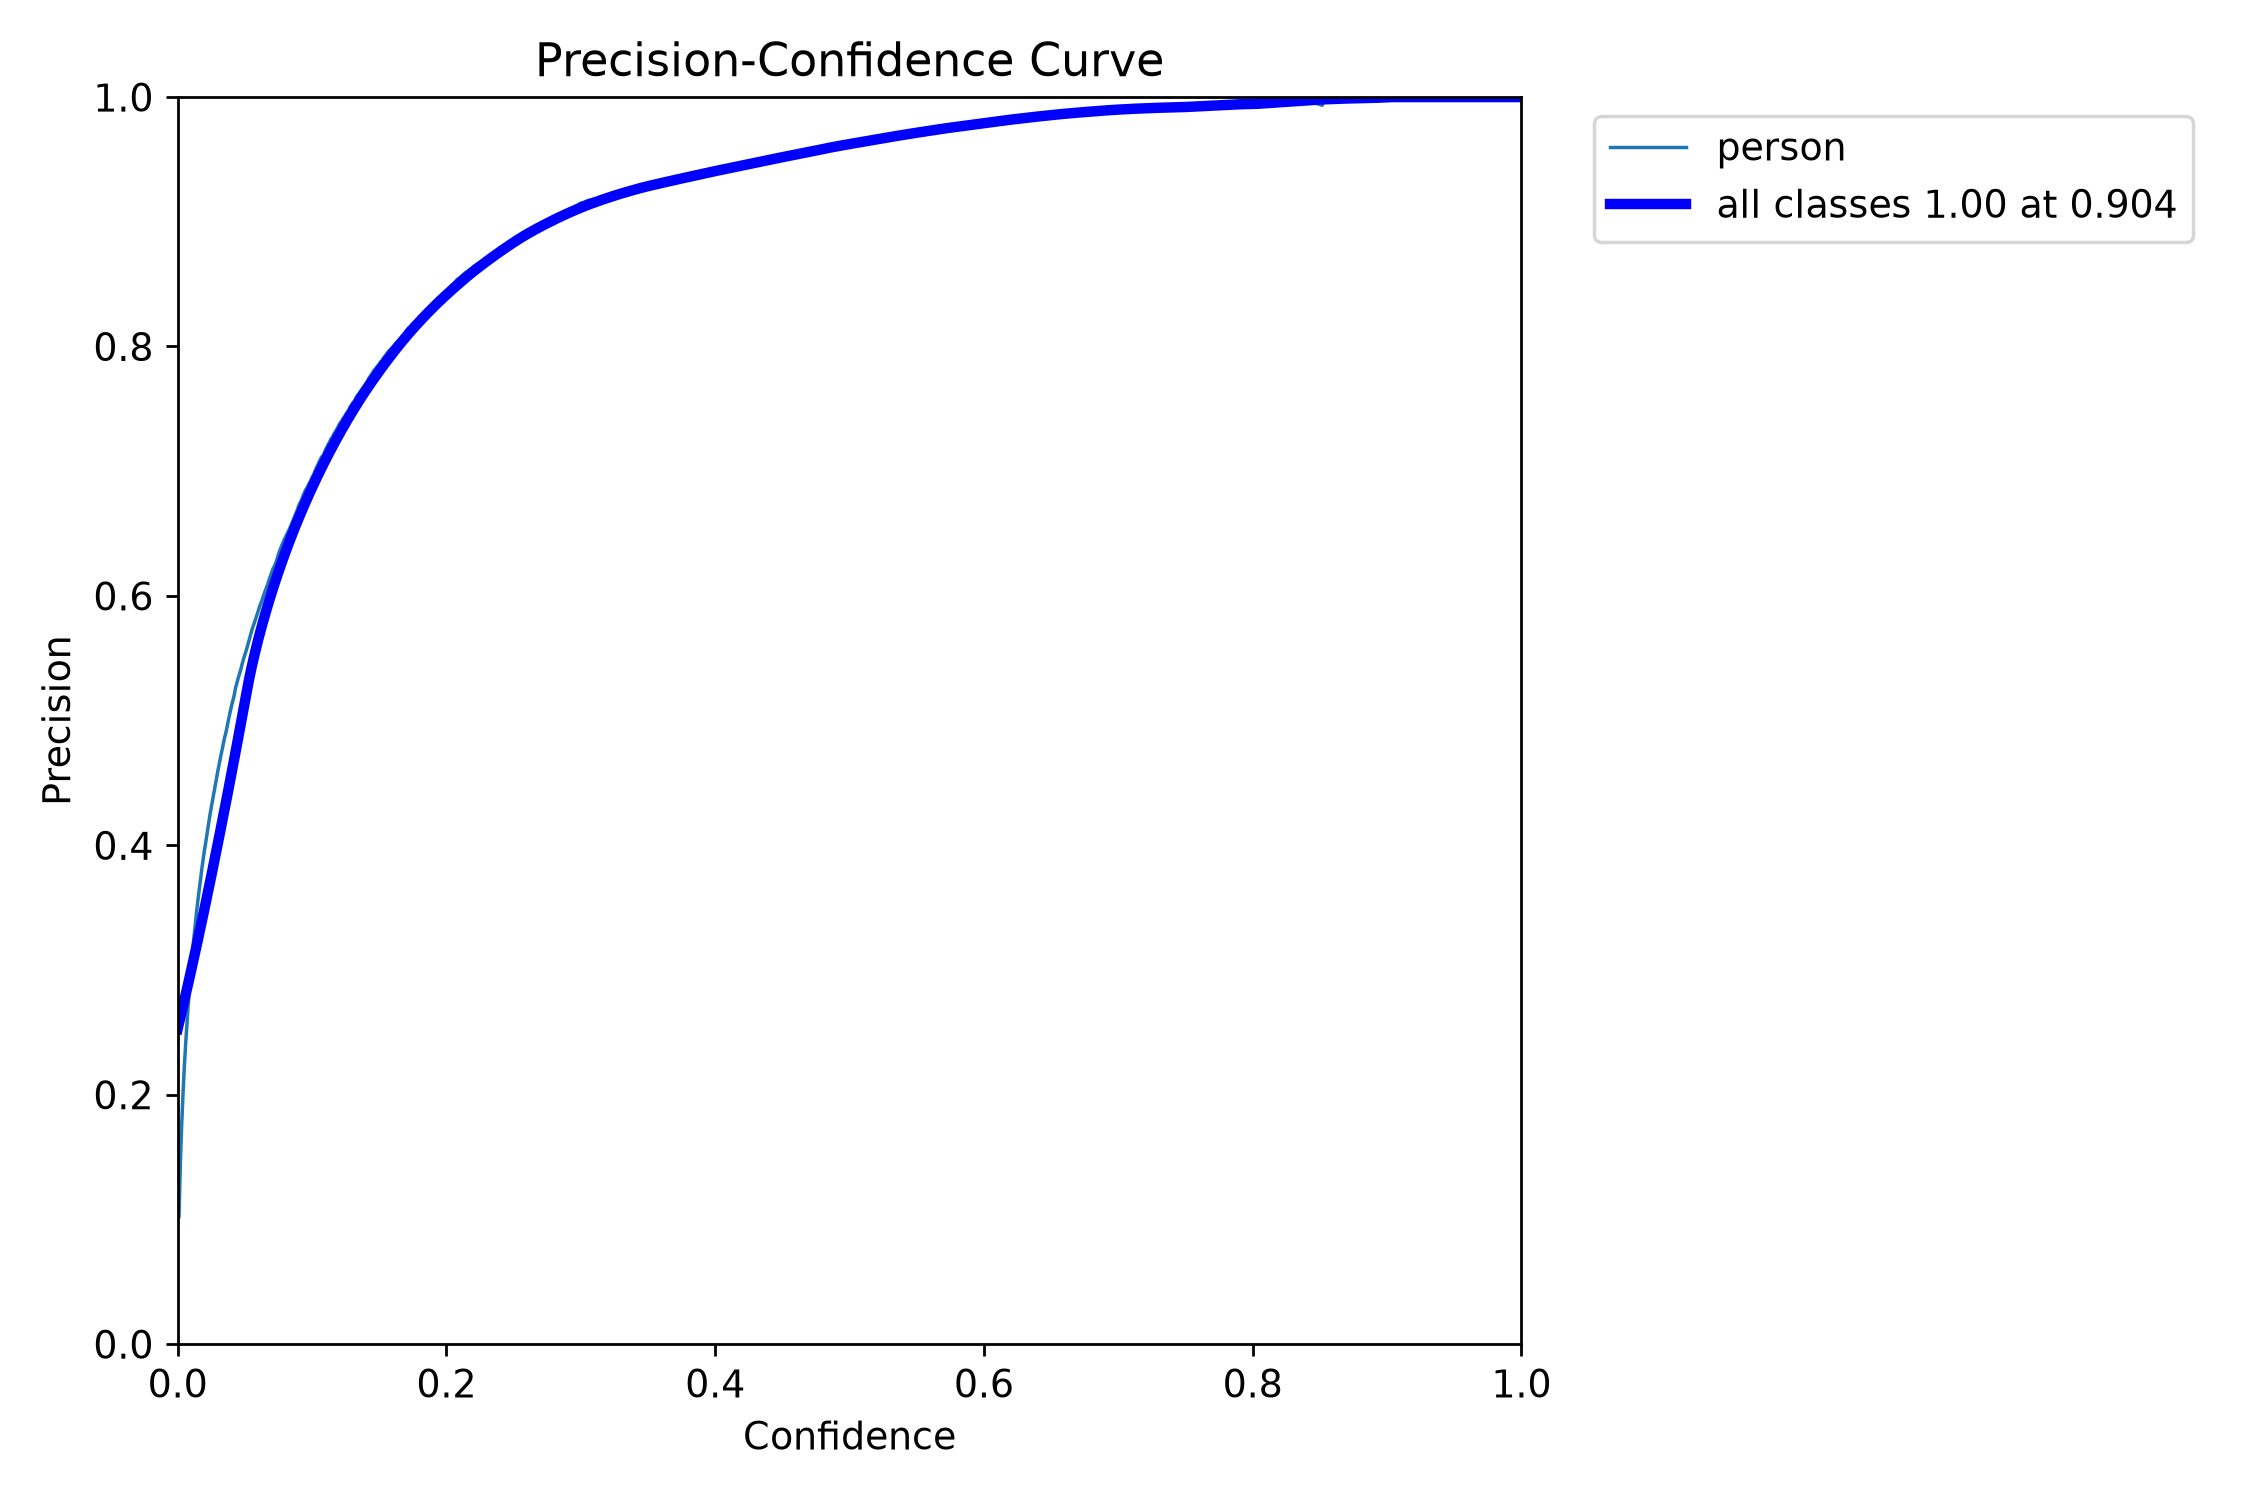

BoxR_curve.png exists: True


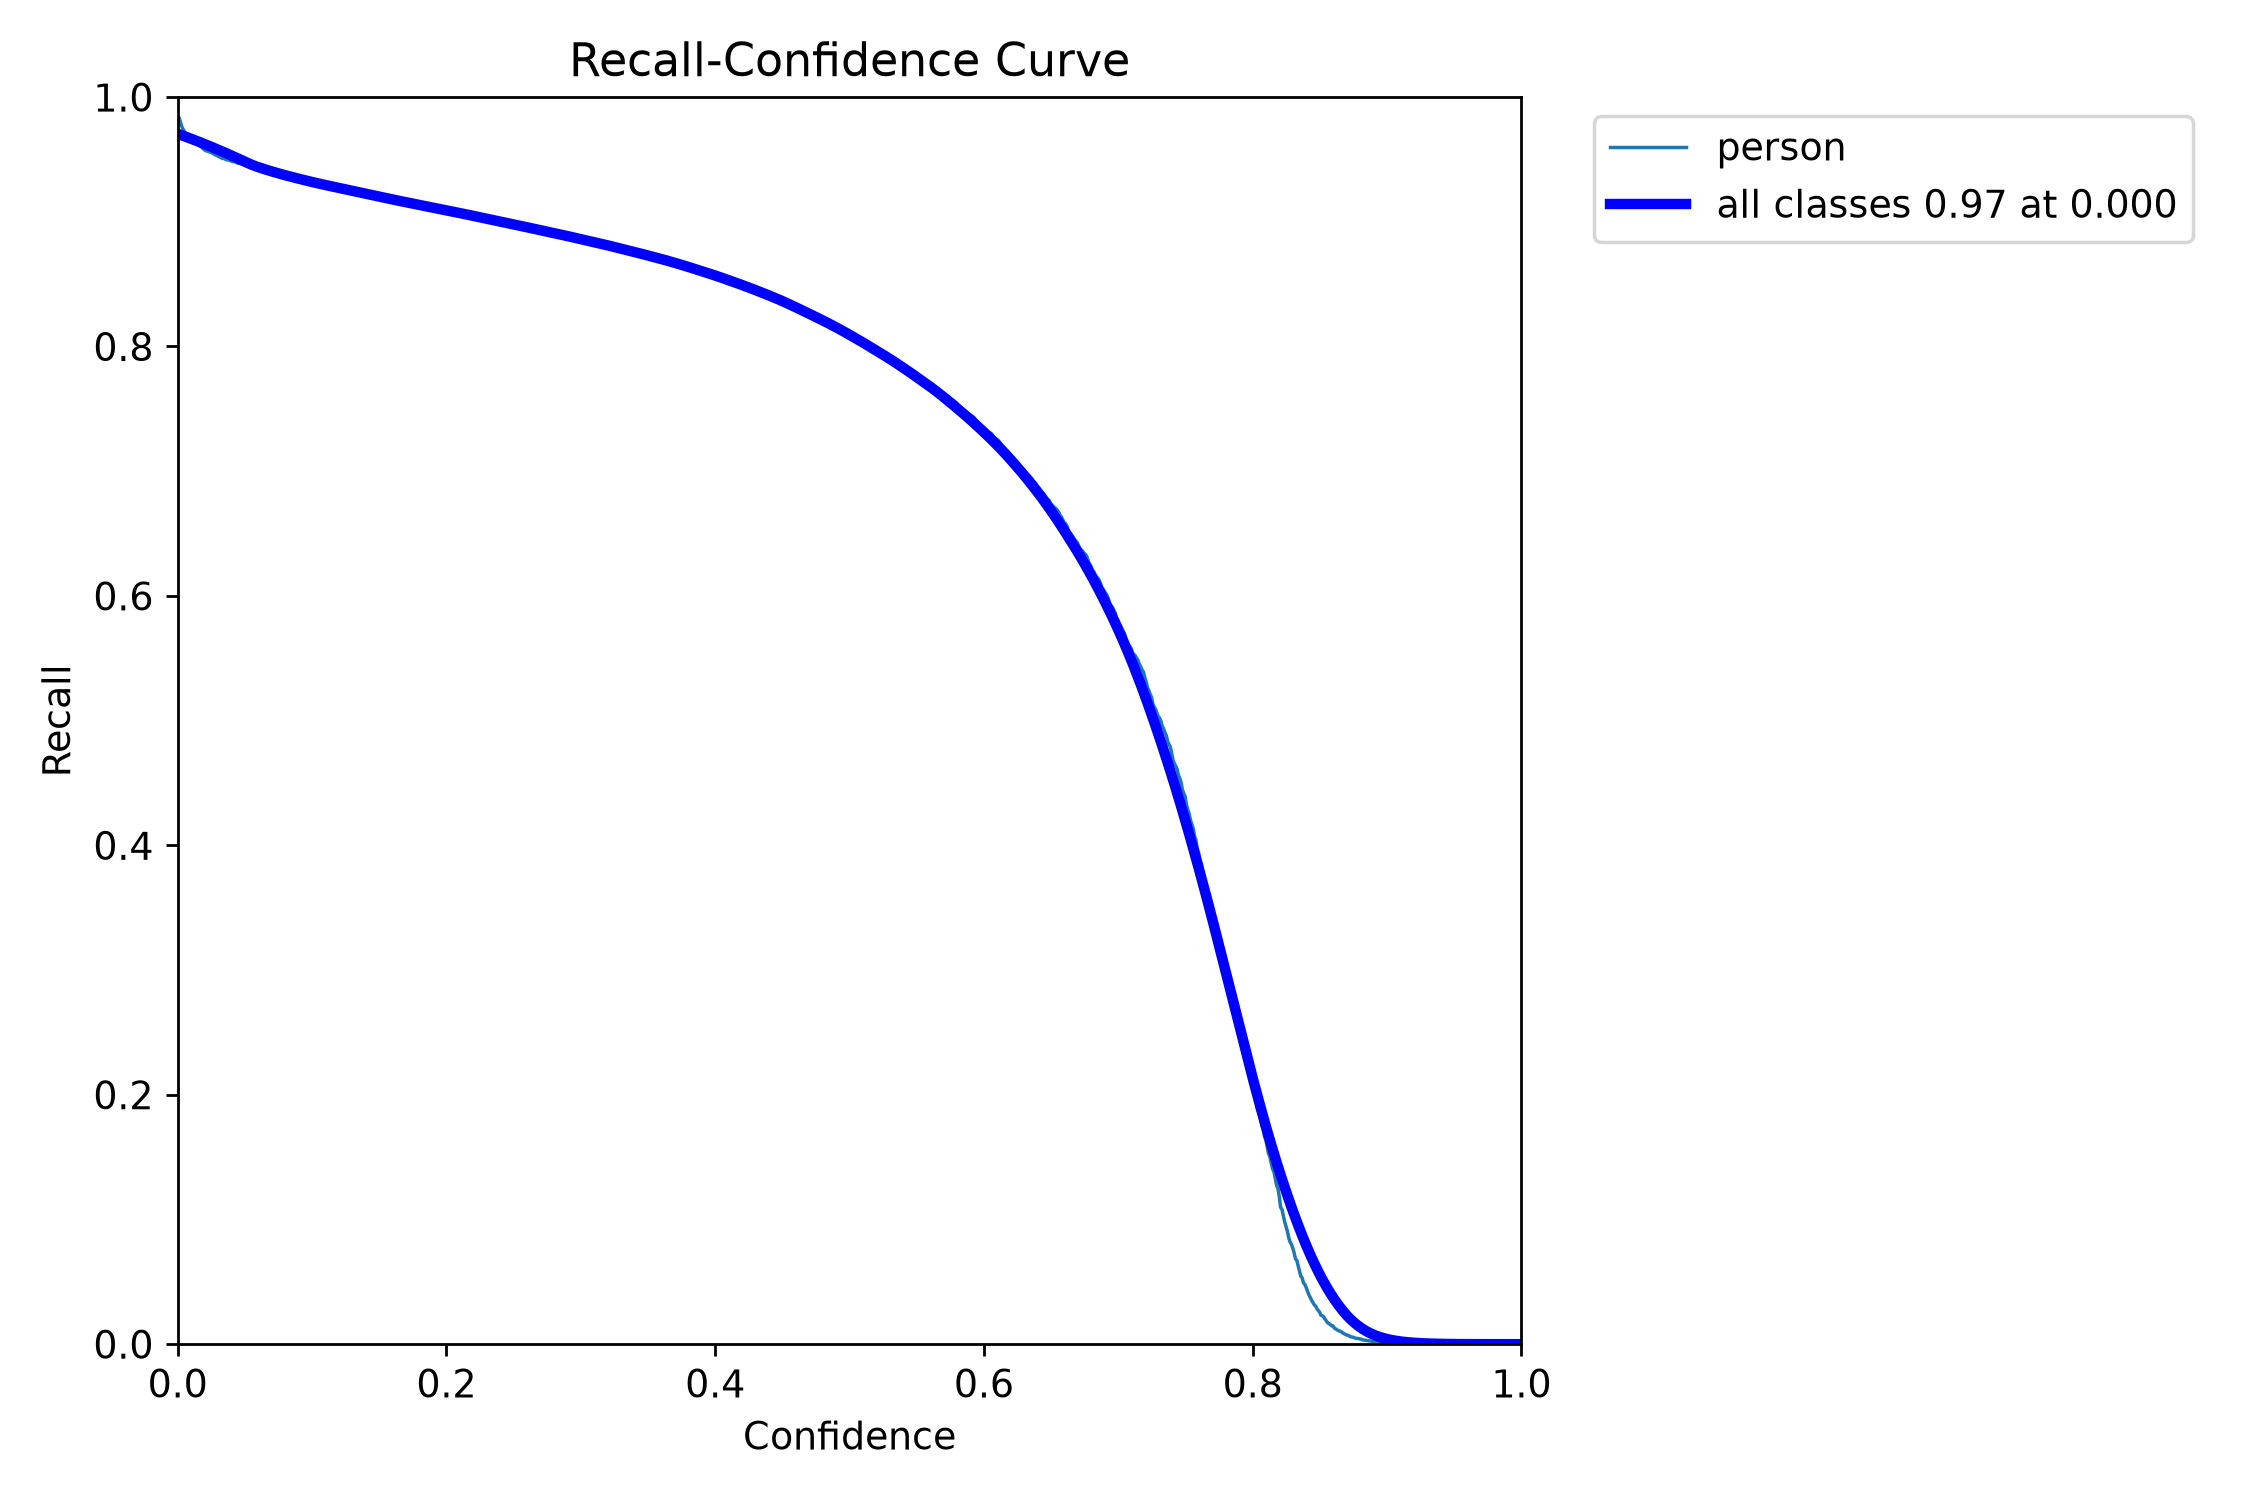

In [40]:
for filename in [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
]:
    file_path = TRAINING_ROOT / filename

    print(filename, "exists:", file_path.exists())

    if file_path.exists():
        display(
            IPImage(
                filename=str(file_path)
            )
        )

In [41]:
model = YOLO(str(BEST_MODEL_PATH))

TEST_EVALUATION_NAME = "test_evaluation_notebook"

test_metrics = model.val(
    data=str(data_yaml_path),
    split="test",
    imgsz=640,
    batch=4,
    device=0,
    workers=0,
    plots=True,
    project=str(RUNS_ROOT),
    name=TEST_EVALUATION_NAME,
    exist_ok=True,
)

test_precision = float(test_metrics.box.mp)
test_recall = float(test_metrics.box.mr)
test_map50 = float(test_metrics.box.map50)
test_map5095 = float(test_metrics.box.map)

test_metrics_dict = {
    "precision": test_precision,
    "recall": test_recall,
    "mAP50": test_map50,
    "mAP50-95": test_map5095,
}

print(json.dumps(test_metrics_dict, indent=2))

(TEST_EVALUATION_NAME + "_metrics.json")

Ultralytics 8.4.163 🚀 Python-3.14.4 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4491.8±943.6 MB/s, size: 341.9 KB)
val: Scanning /home/arjun/lli-pedestrian/data/yolo/labels/test... 3463 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3463/3463 1.7Kit/s 2.1s0.1s
val: New cache created: /home/arjun/lli-pedestrian/data/yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 866/866 19.7it/s 44.1s0.1ss
                   all       3463       8302      0.899      0.814      0.886      0.502
Speed: 0.5ms preprocess, 3.8ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /home/arjun/lli-pedestrian/runs/test_evaluation_notebook
{
  "precision": 0.8990944068002886,
  "recall": 0.8142616237051313,
  "mAP50": 0.885959687681916,
  "mAP50-95": 0.5

'test_evaluation_notebook_metrics.json'

In [42]:
TEST_RESULTS_ROOT = (
    RUNS_ROOT
    / TEST_EVALUATION_NAME
)

TEST_RESULTS_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

test_metrics_path = (
    TEST_RESULTS_ROOT
    / "test_metrics.json"
)

test_metrics_path.write_text(
    json.dumps(
        test_metrics_dict,
        indent=2,
    )
)

print("Saved test metrics to:", test_metrics_path)

Saved test metrics to: /home/arjun/lli-pedestrian/runs/test_evaluation_notebook/test_metrics.json


confusion_matrix.png exists: True


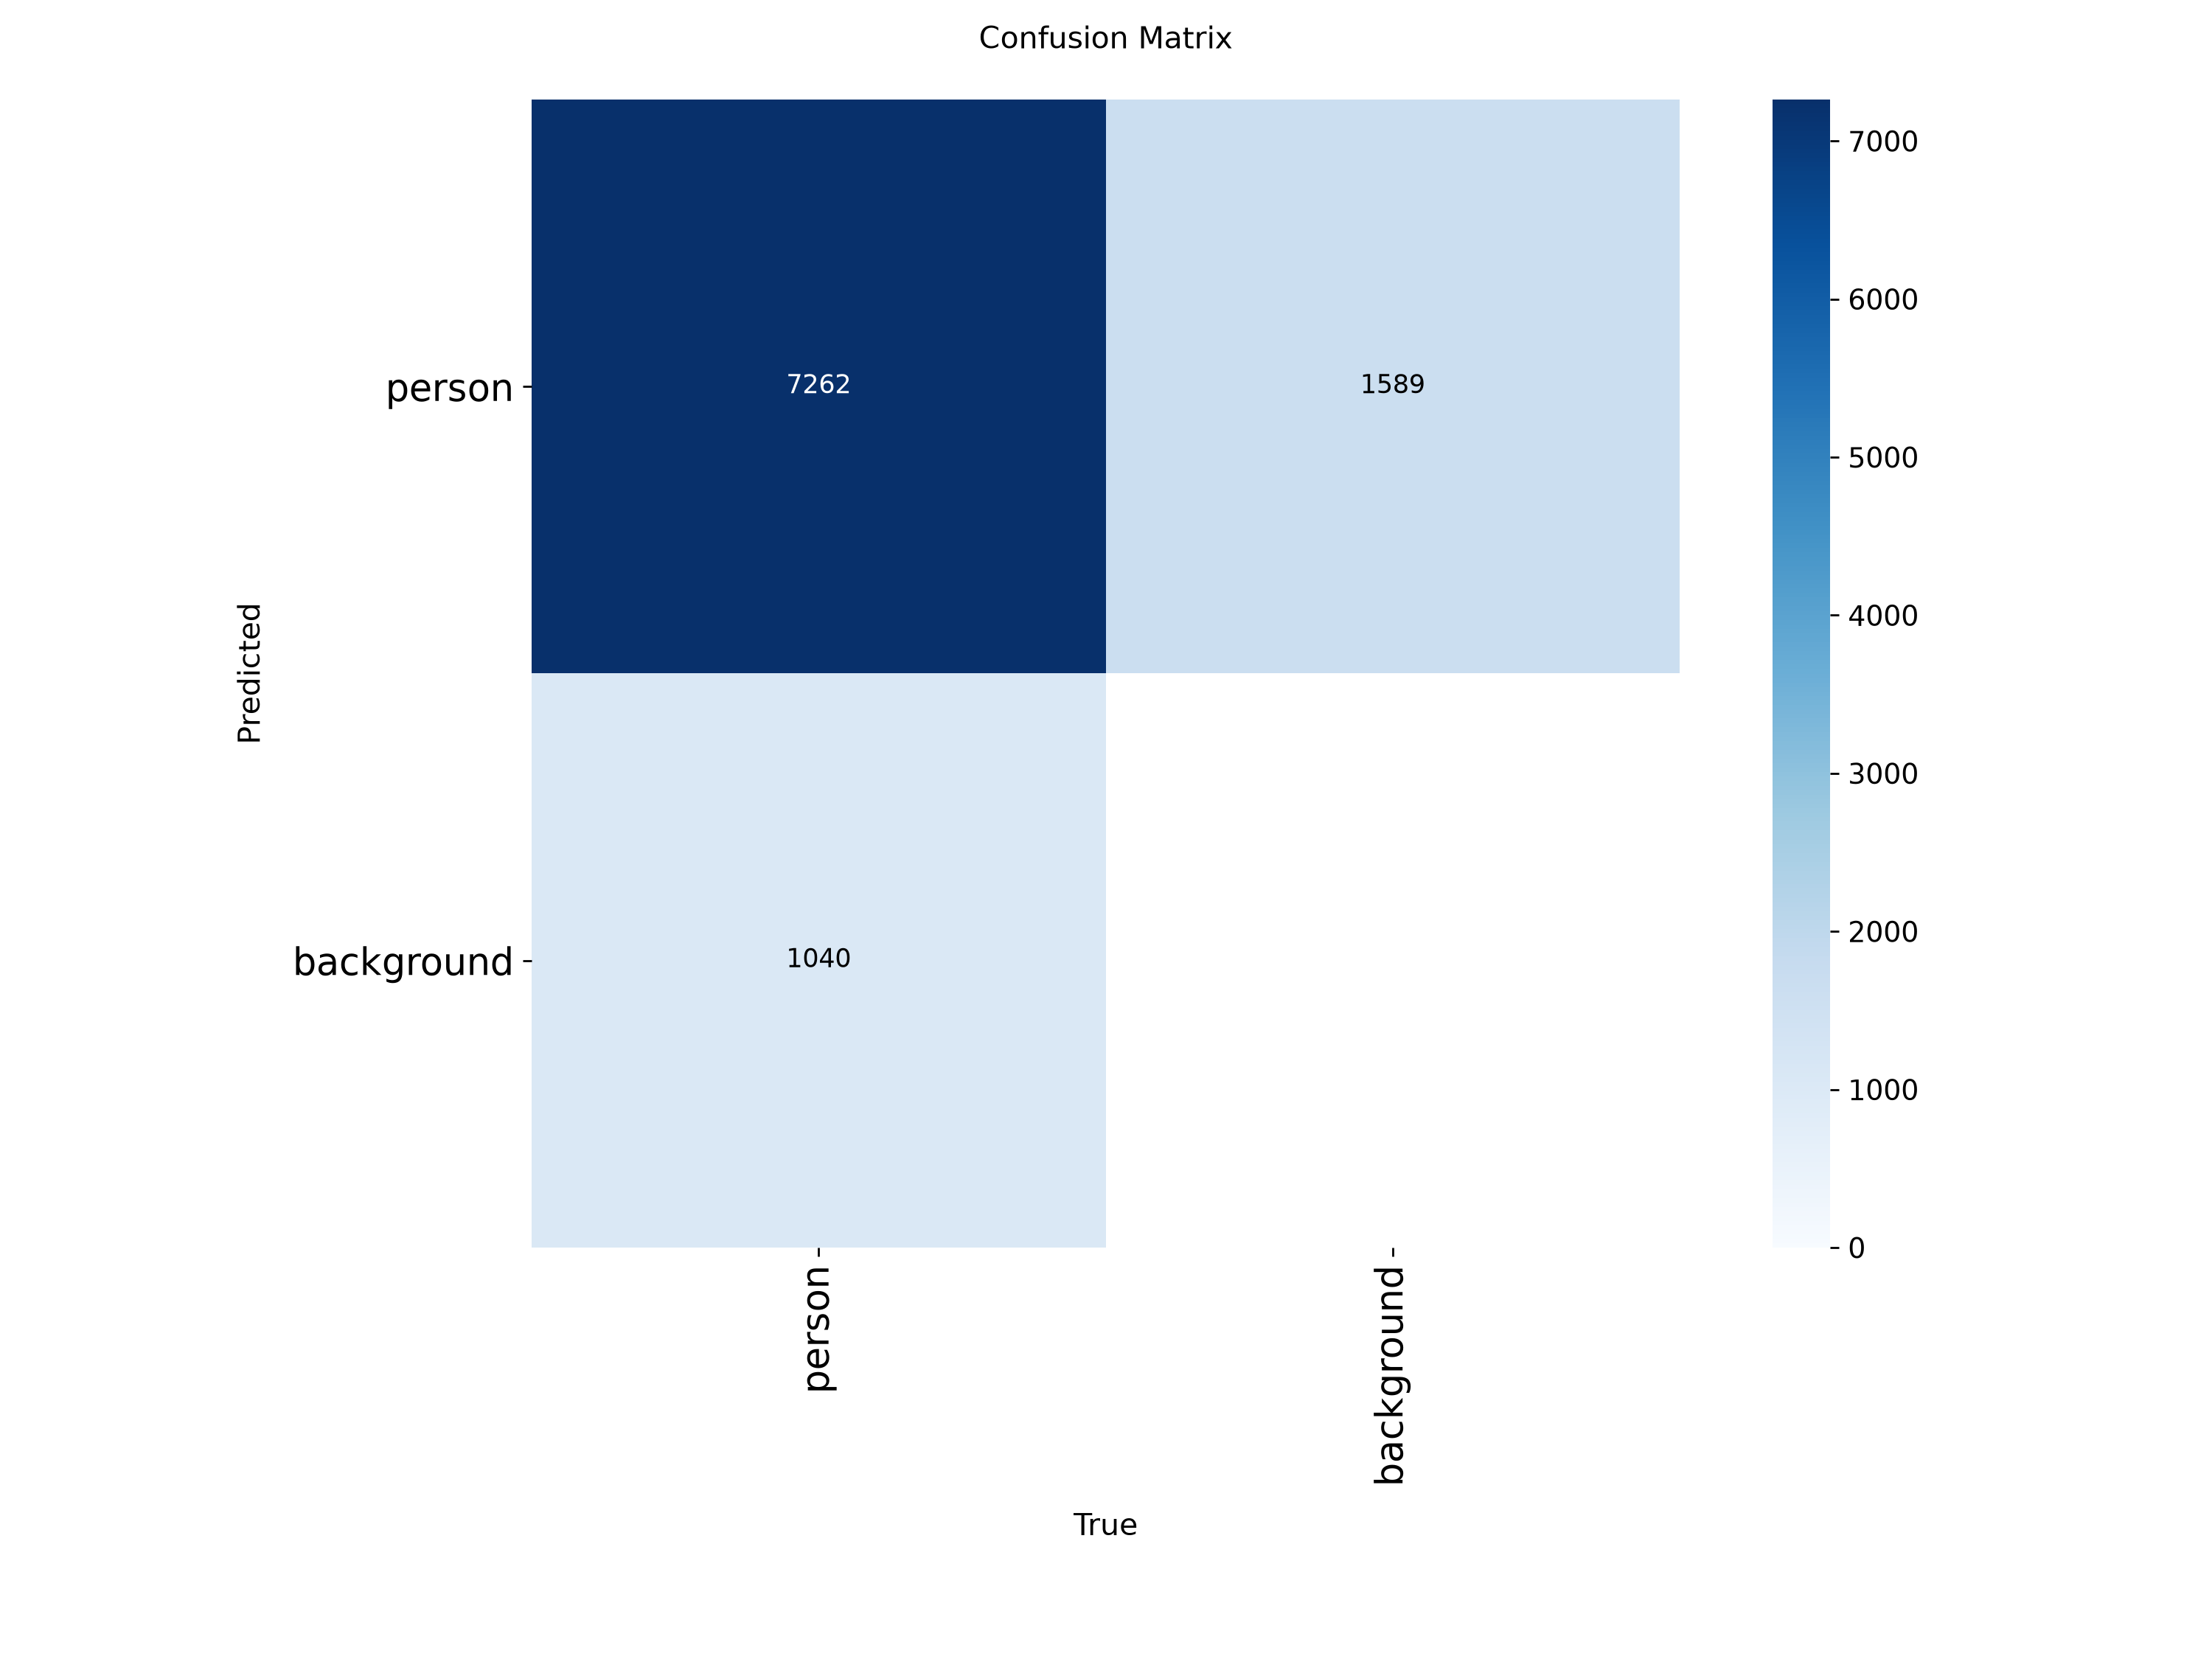

confusion_matrix_normalized.png exists: True


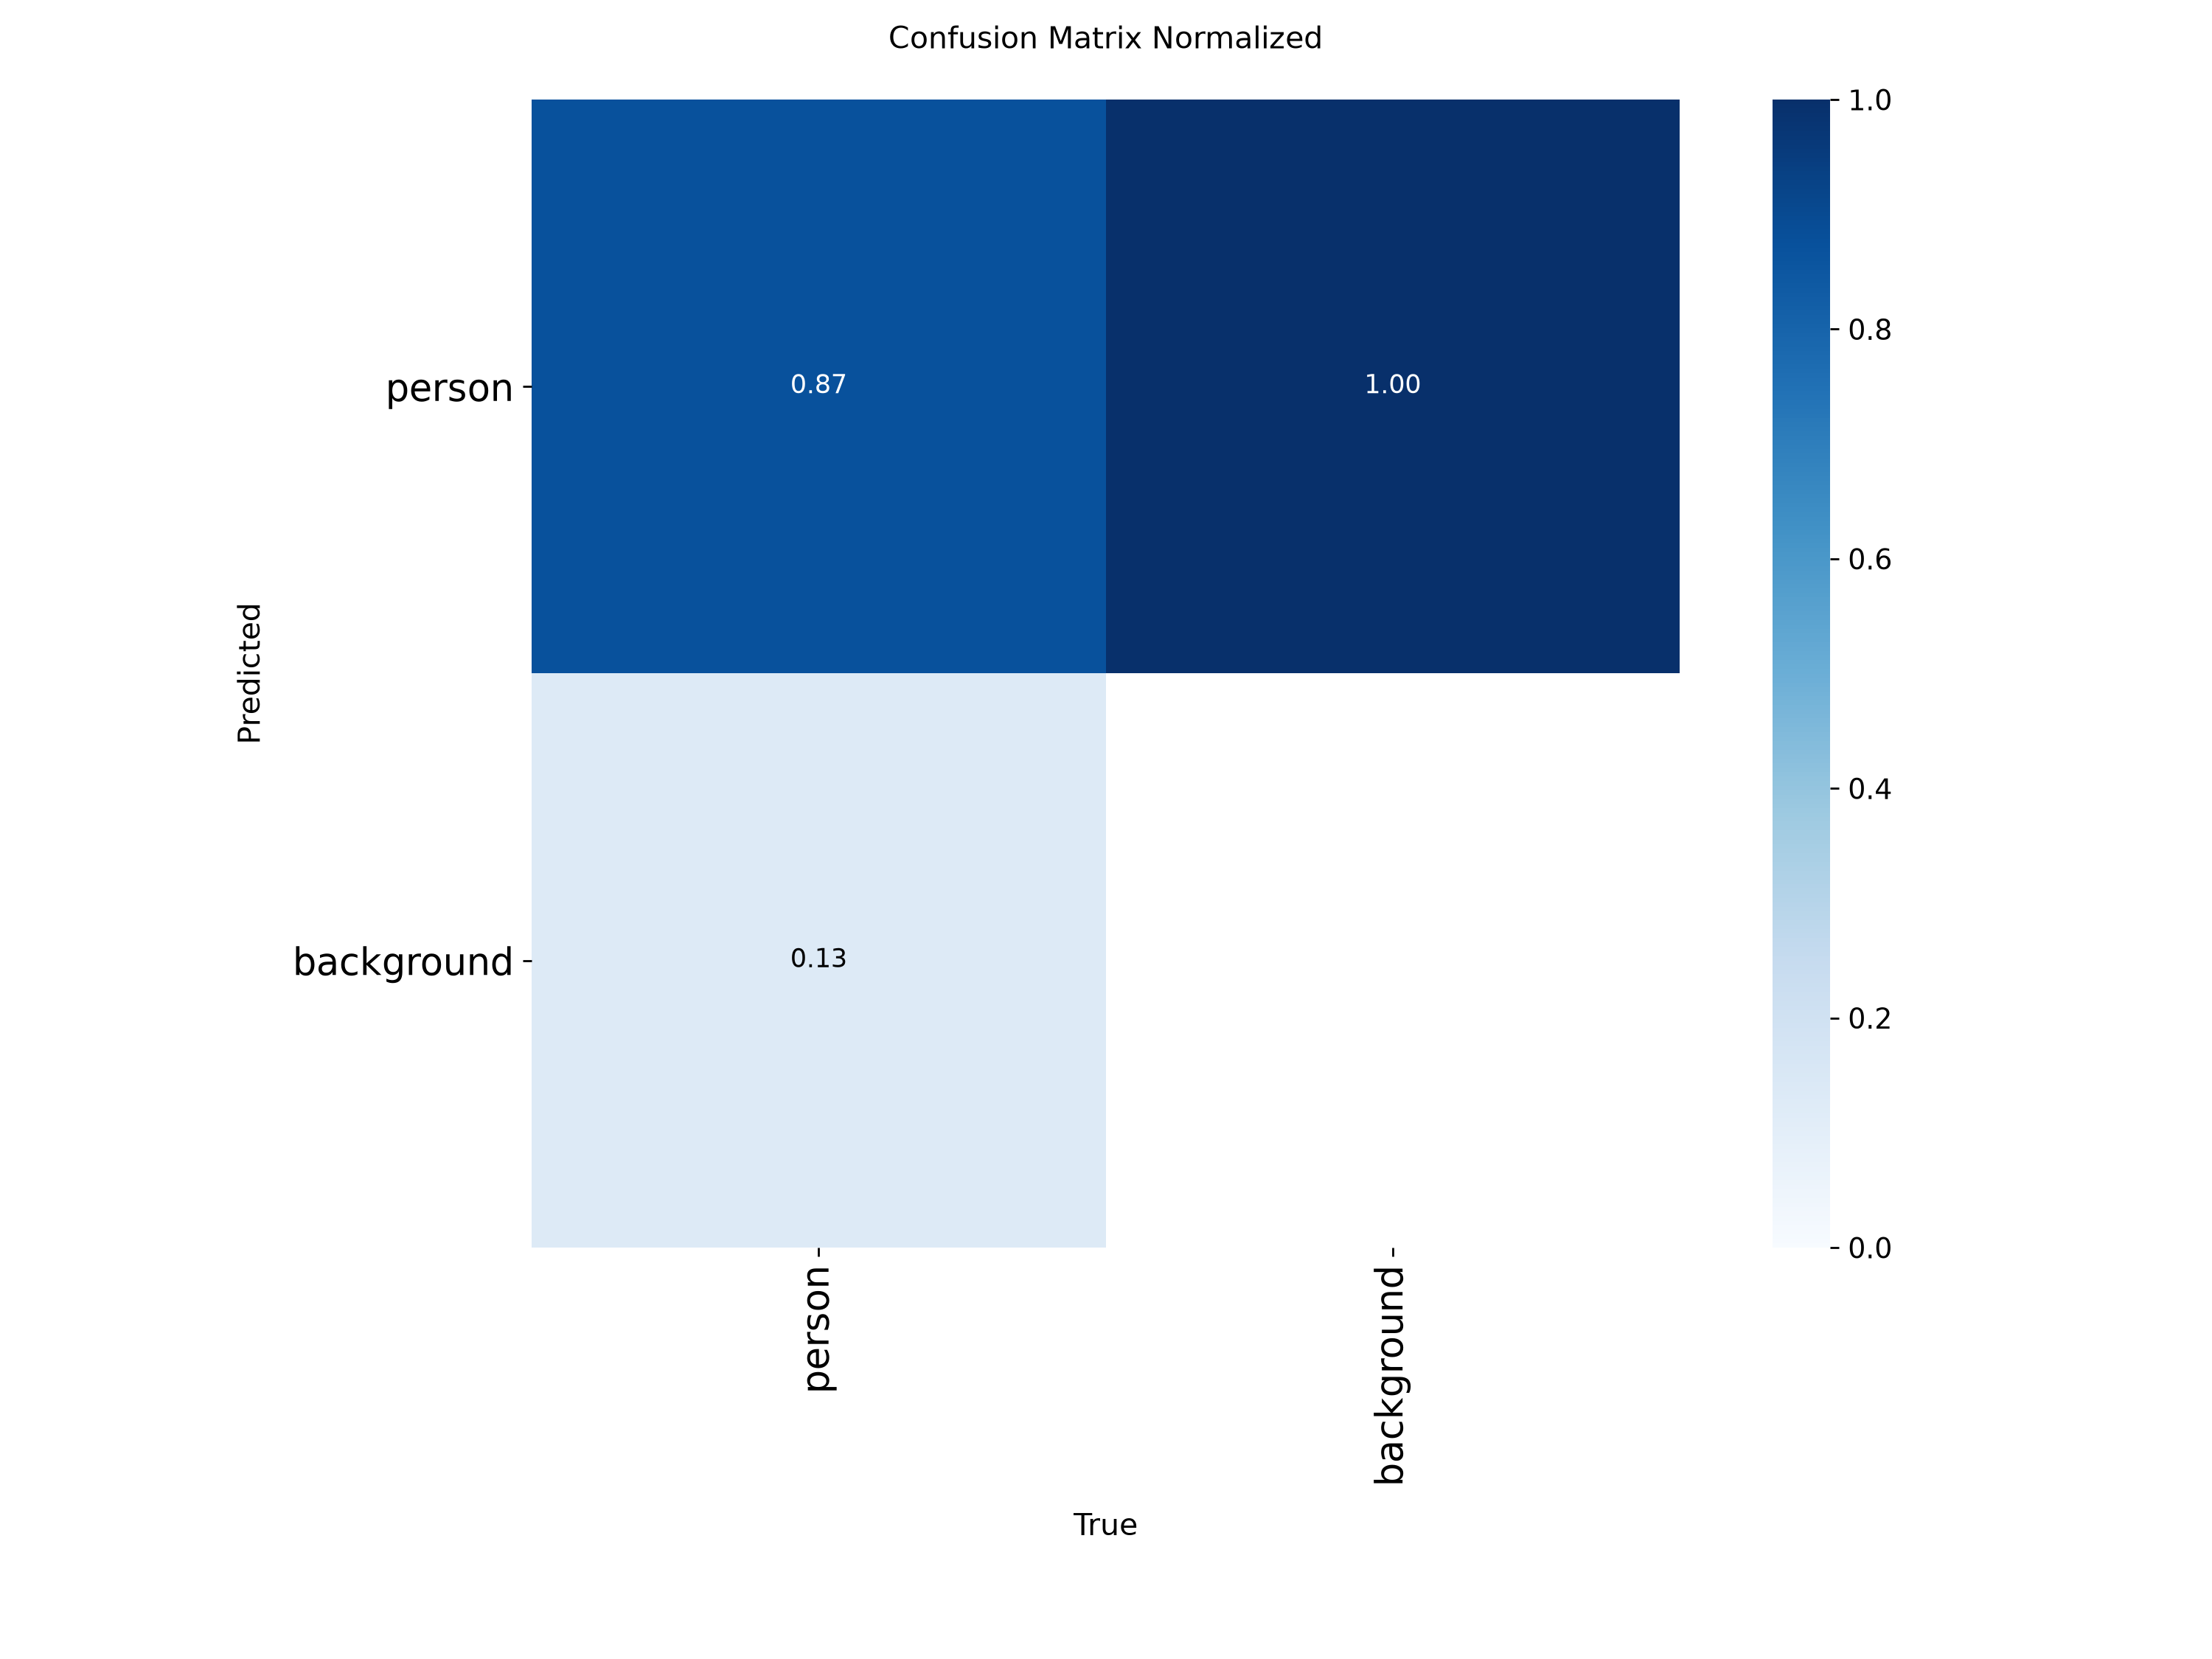

BoxPR_curve.png exists: True


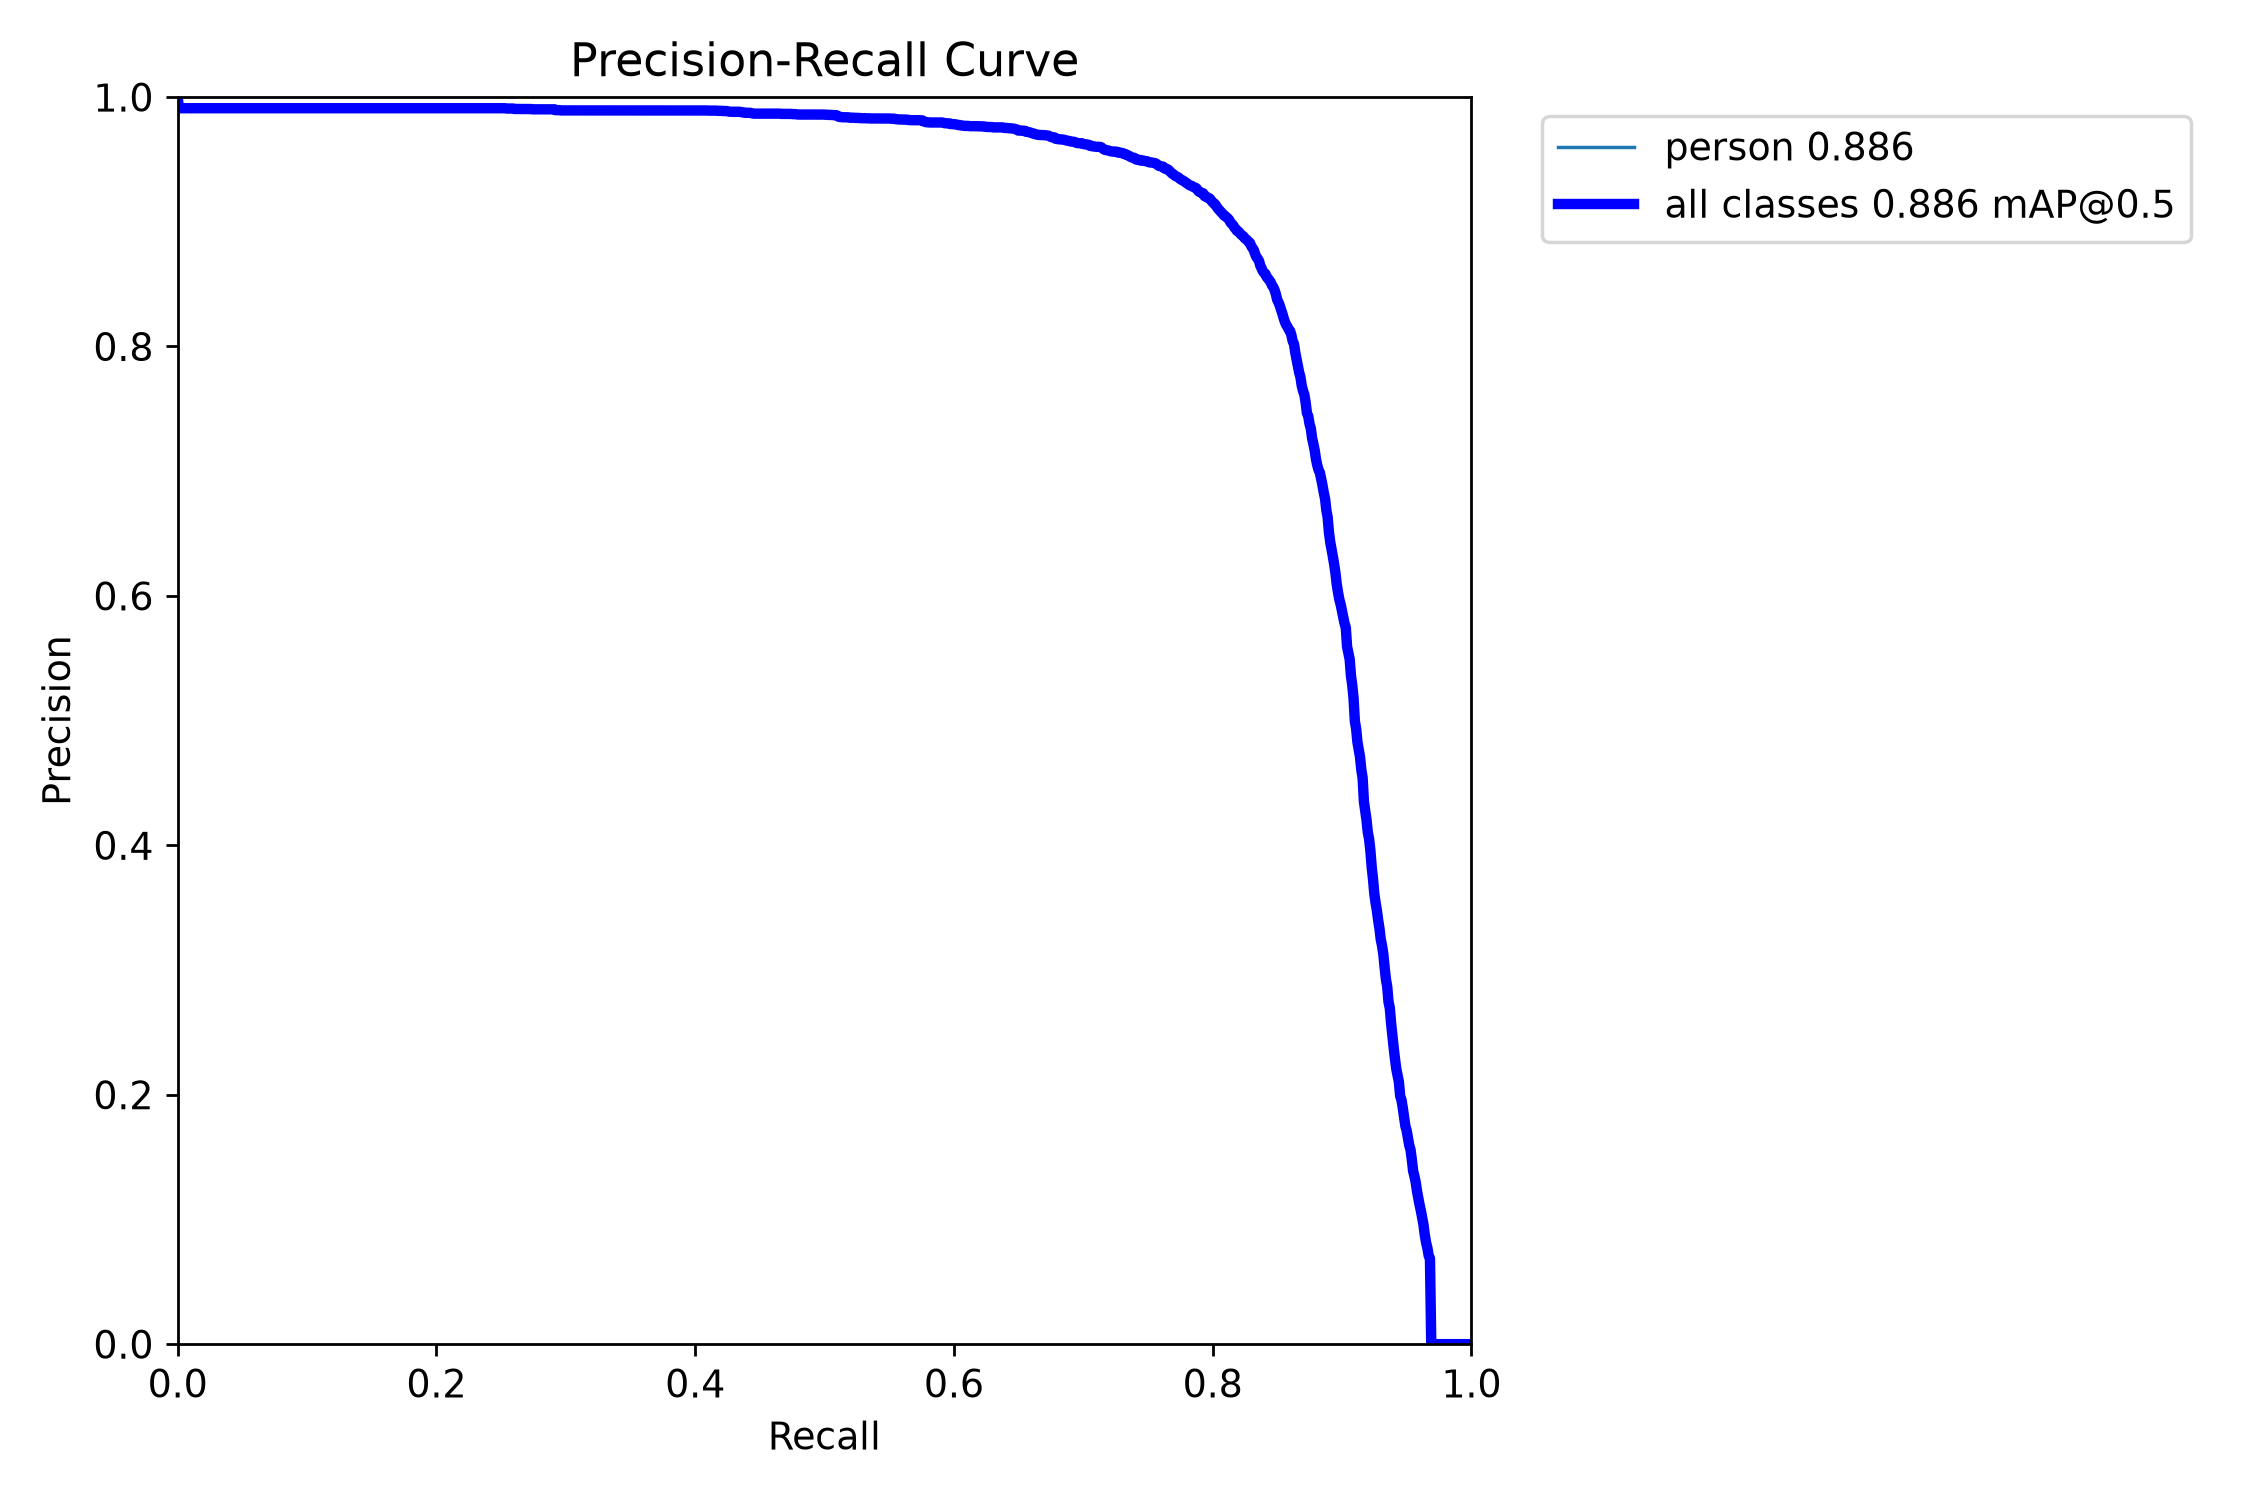

BoxF1_curve.png exists: True


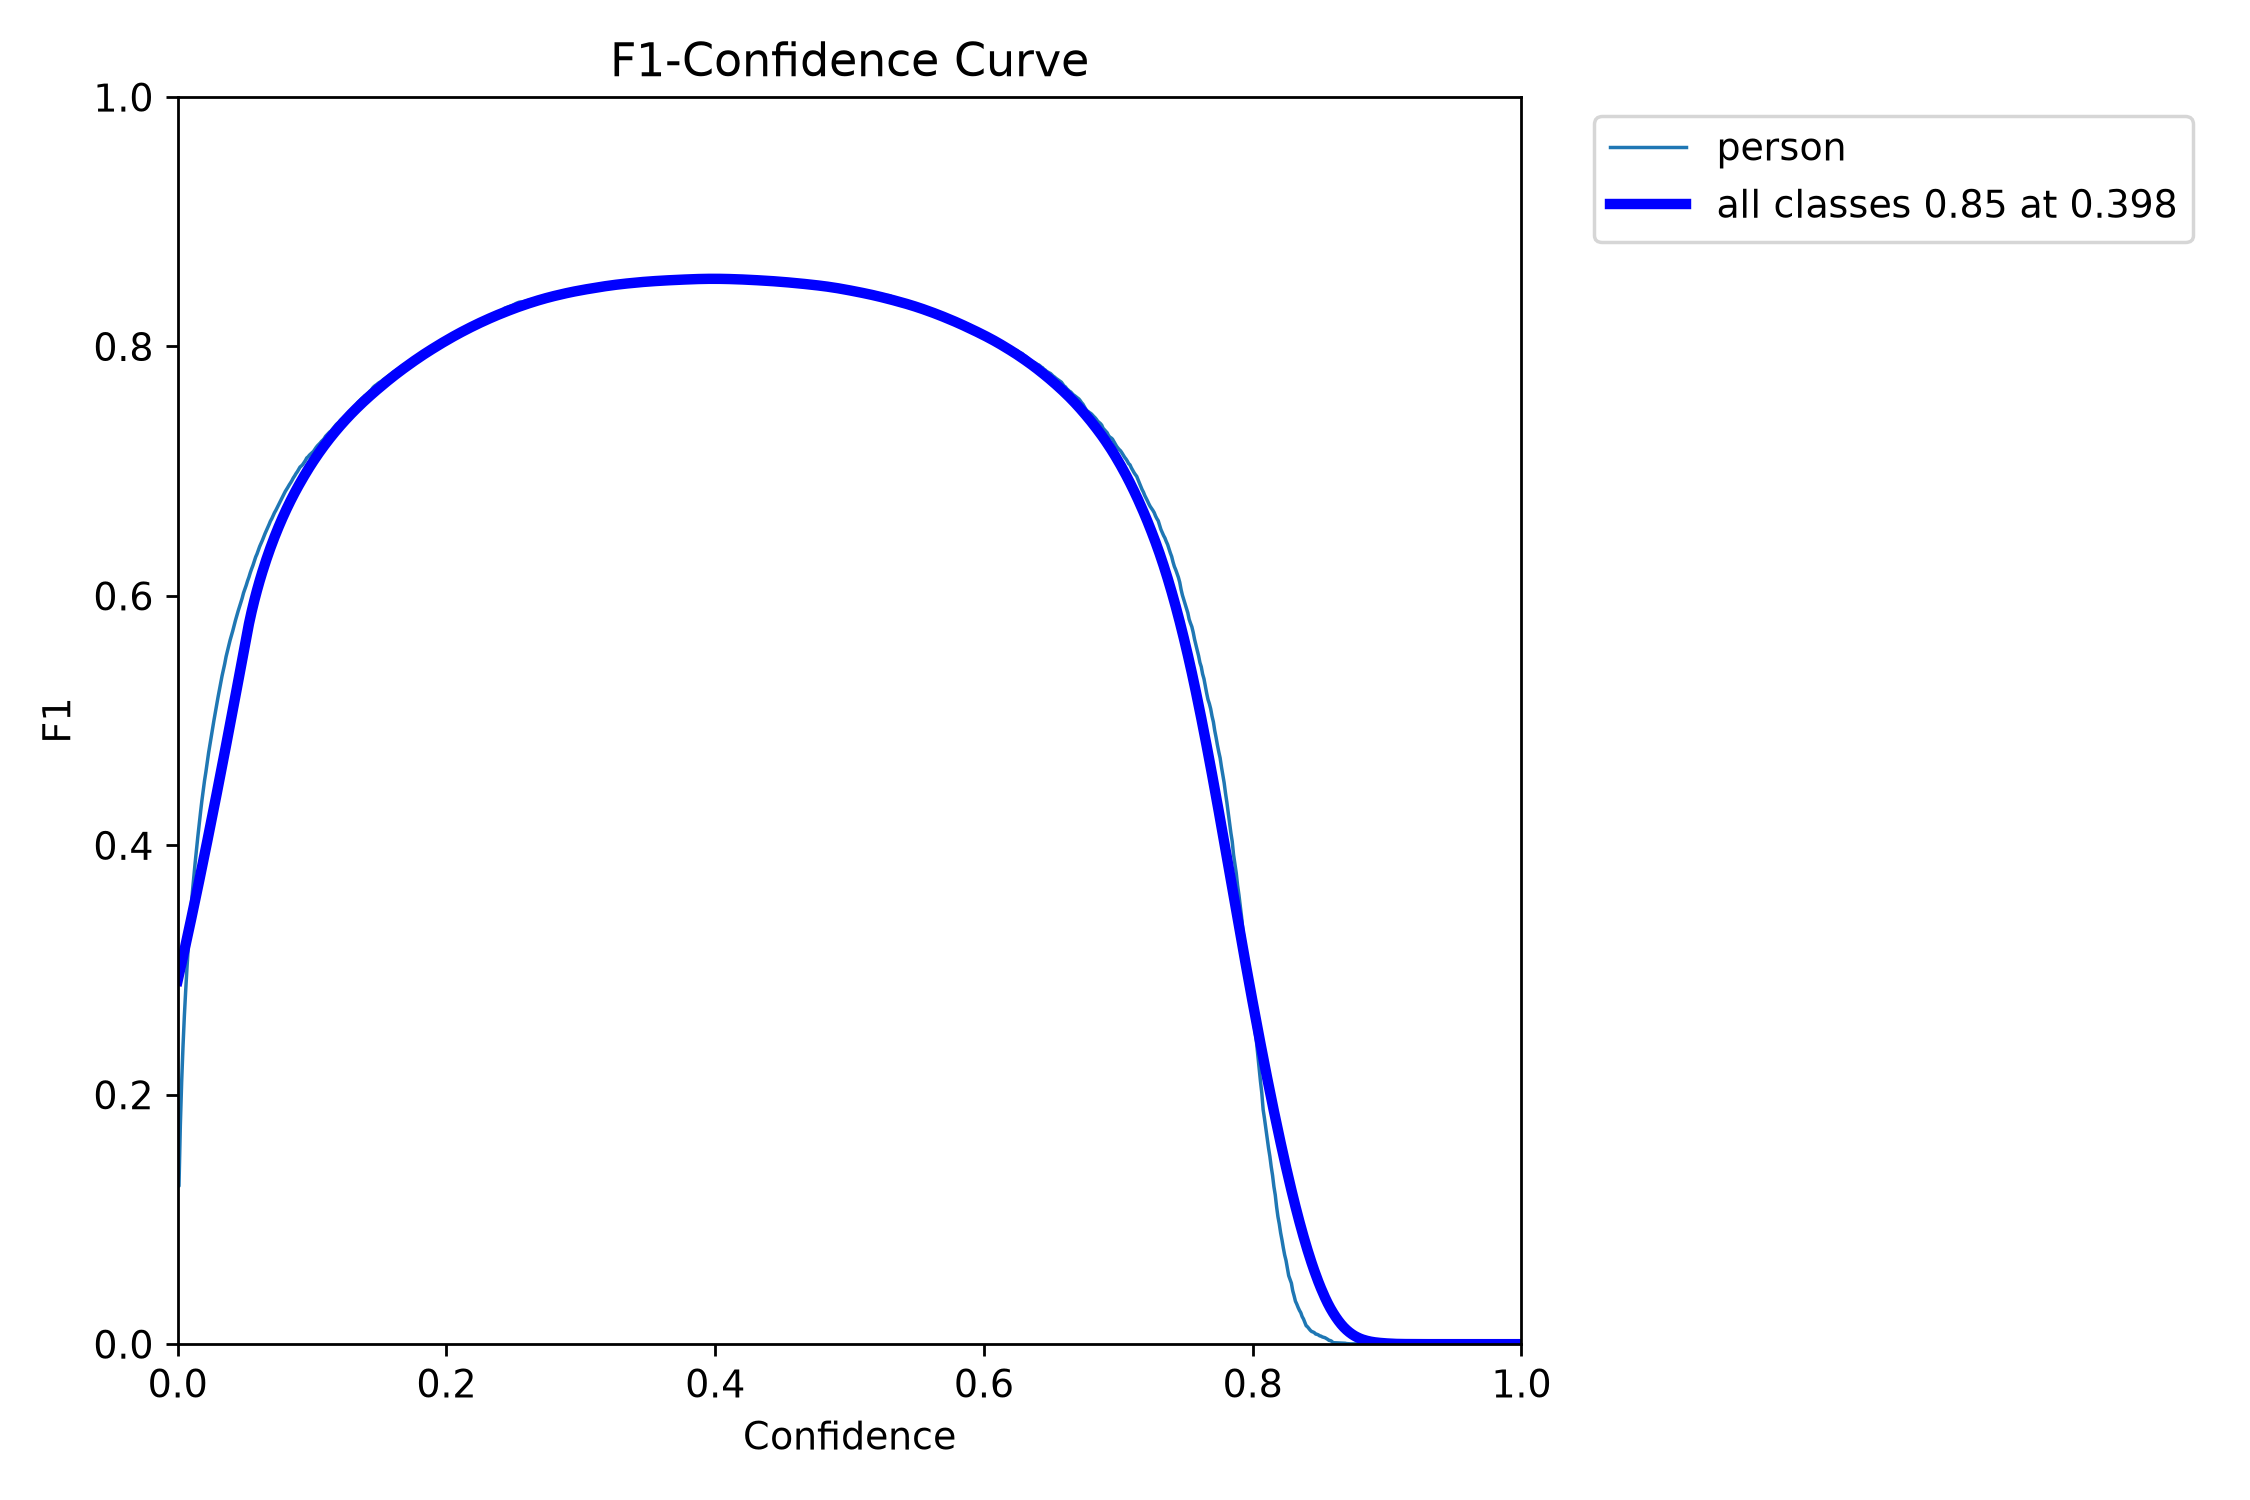

BoxP_curve.png exists: True


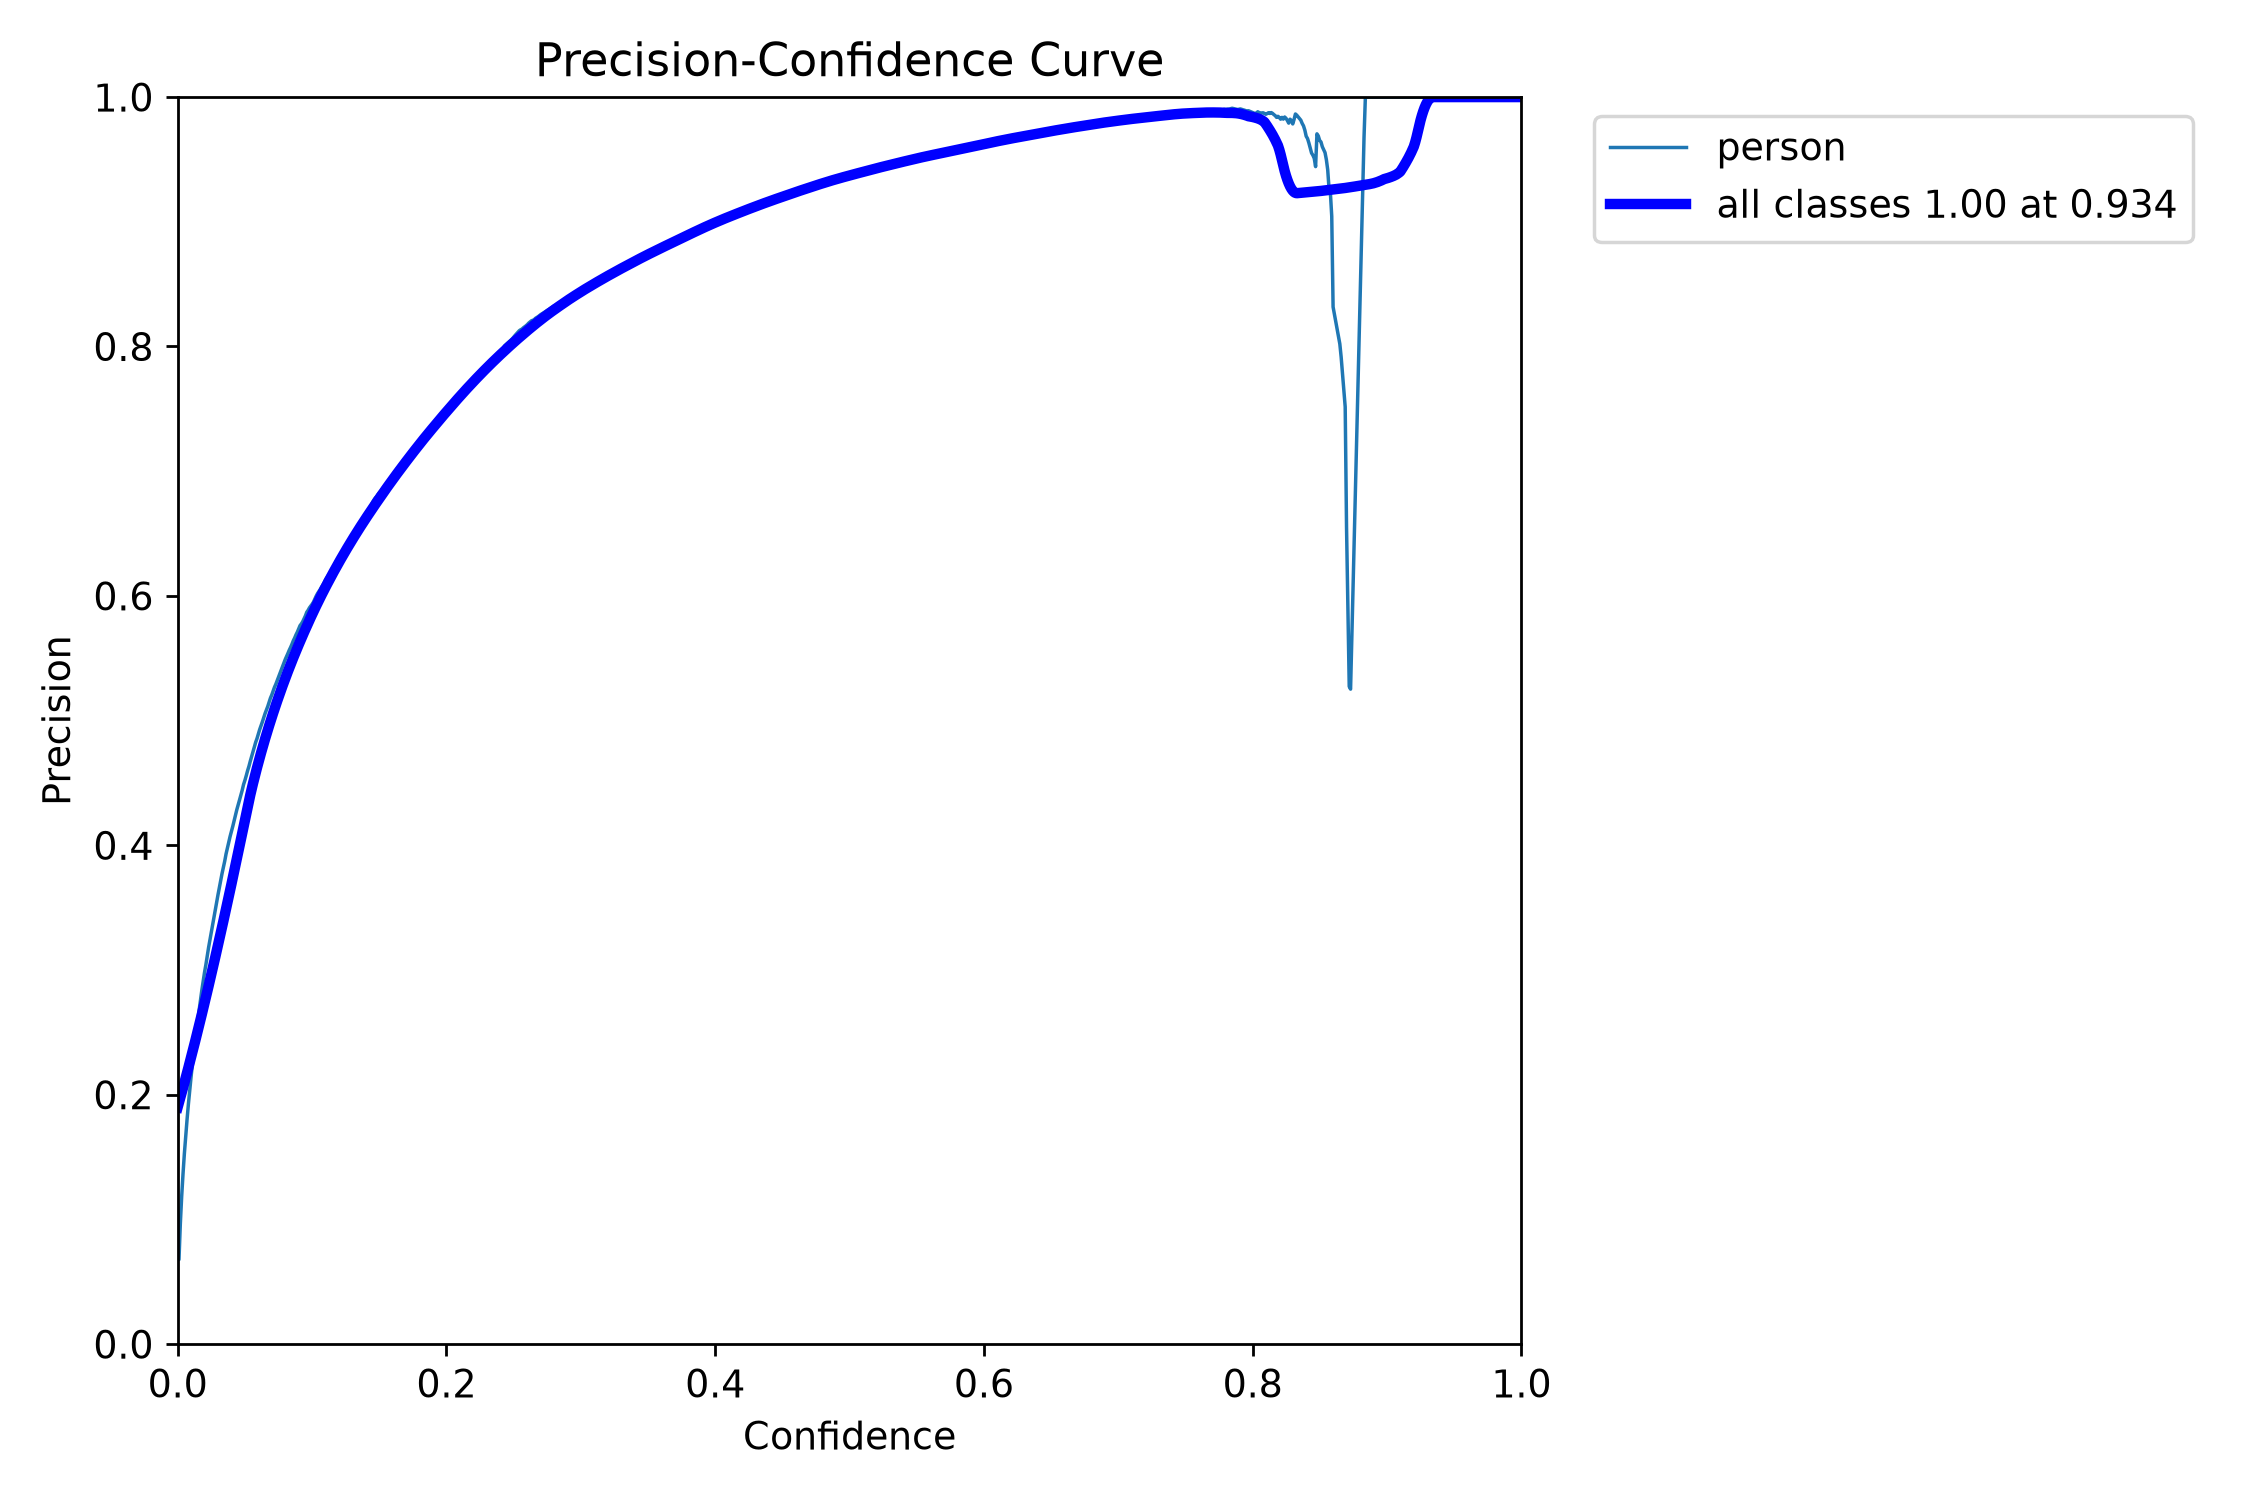

BoxR_curve.png exists: True


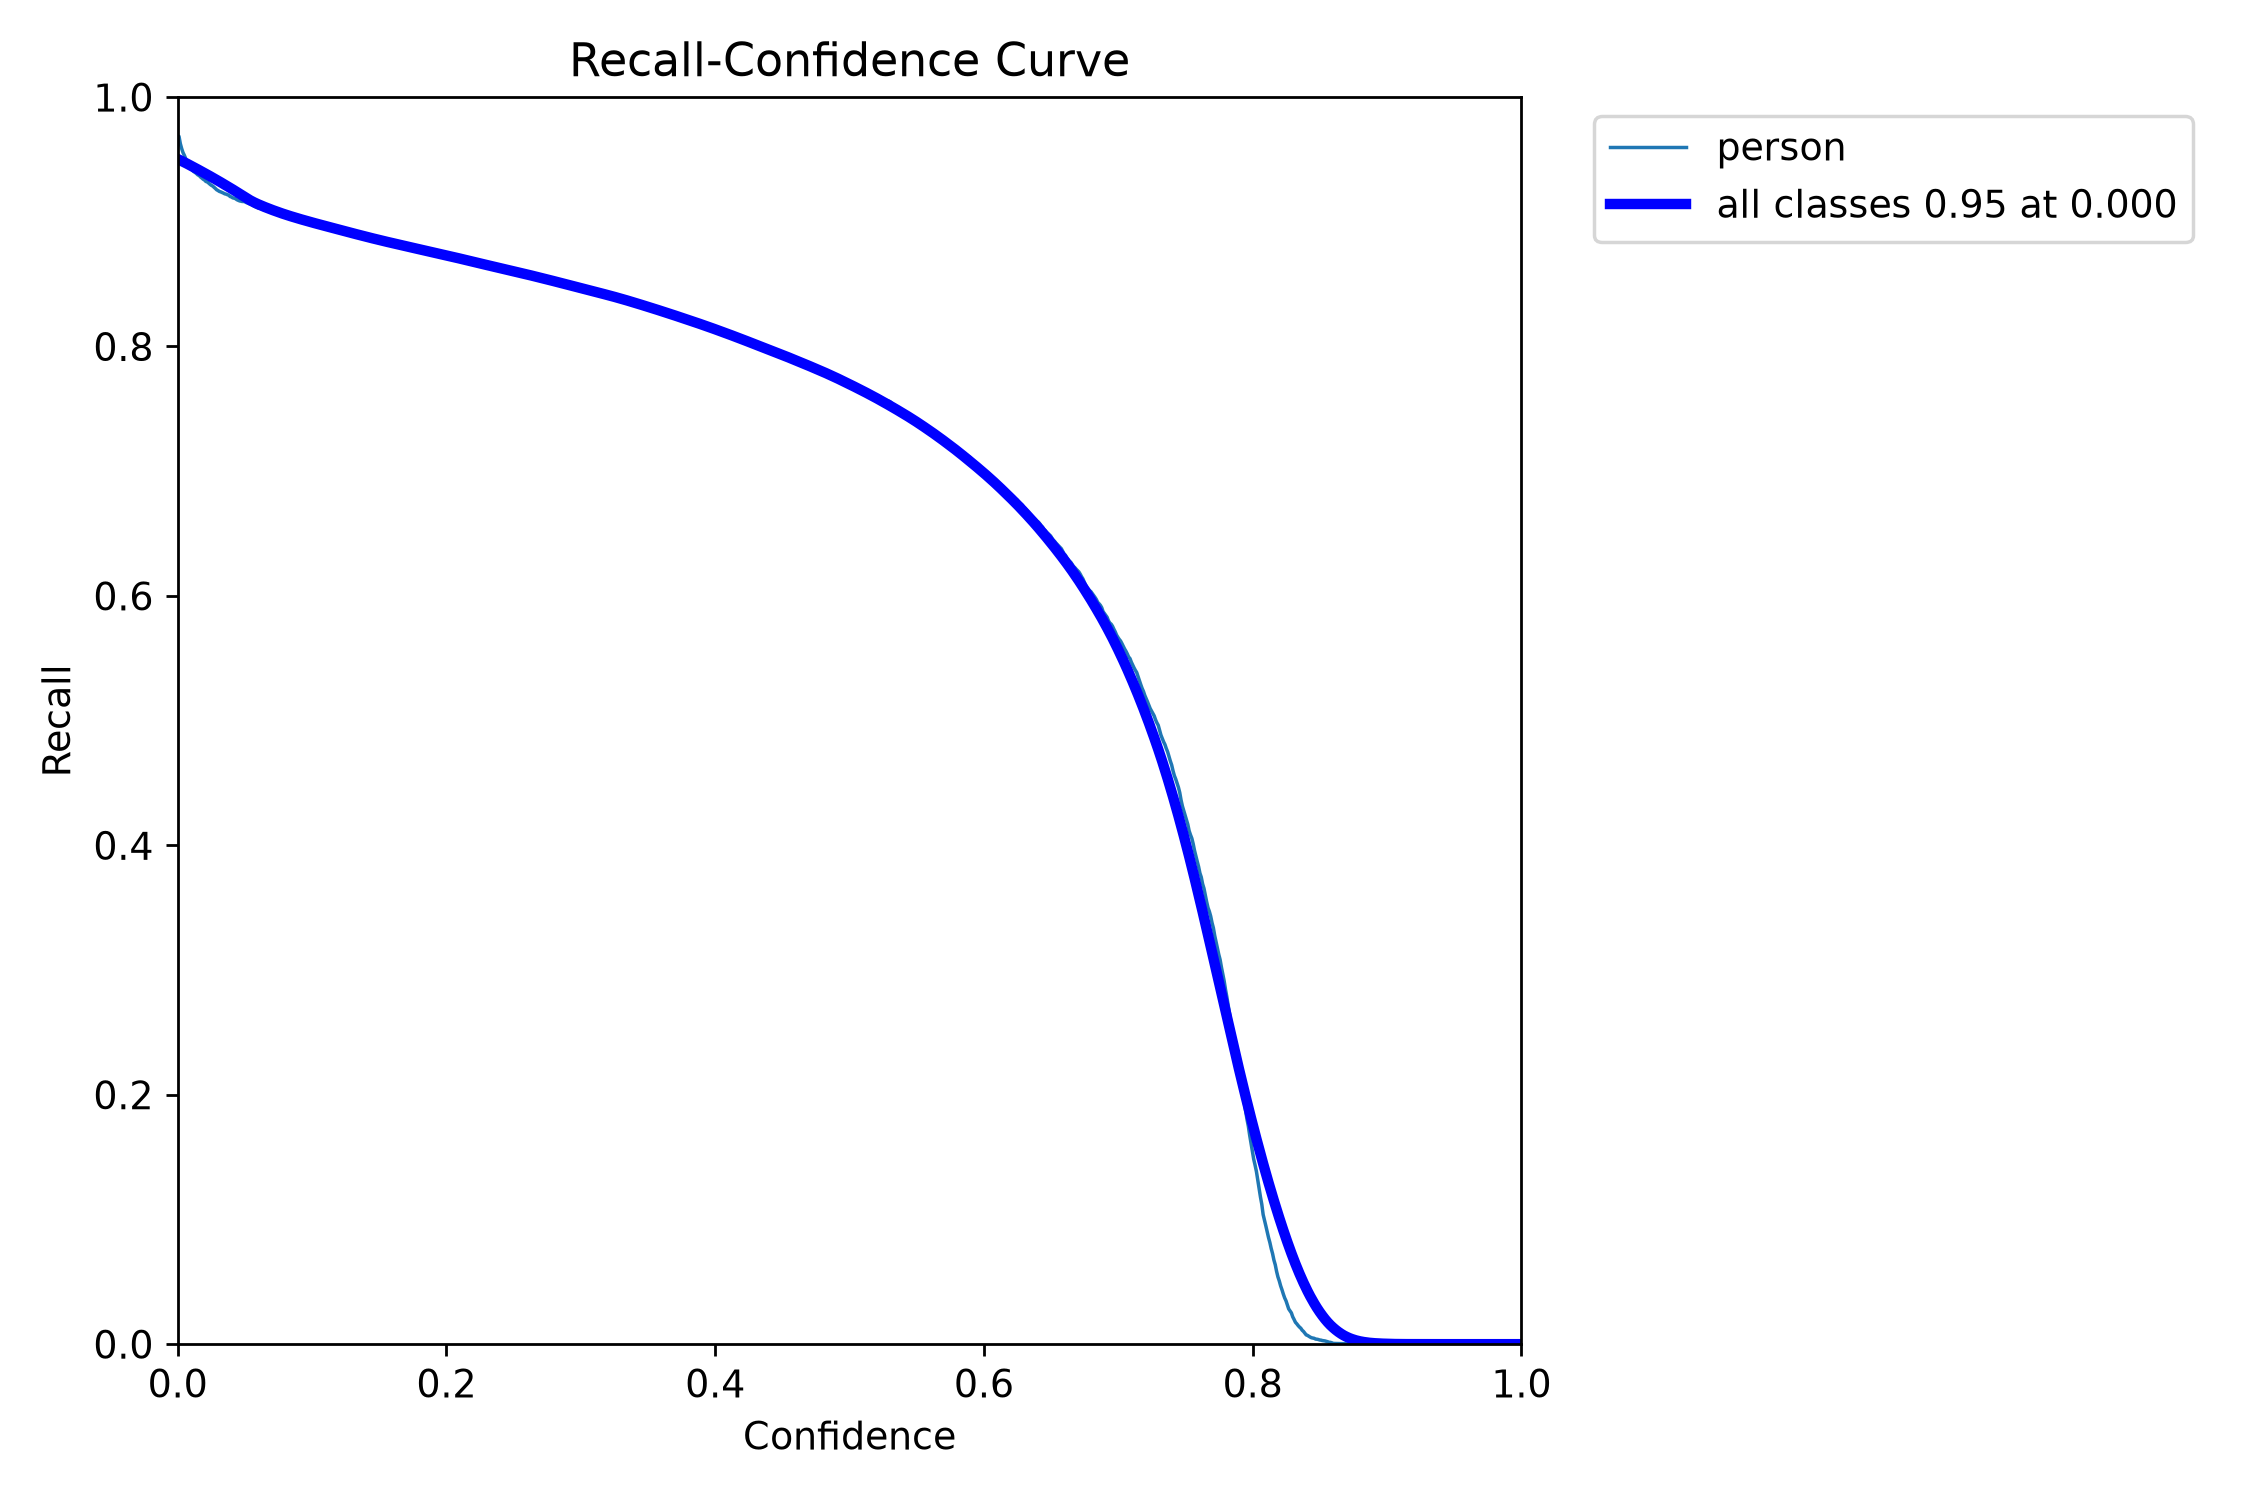

In [43]:
for filename in [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
]:
    file_path = TEST_RESULTS_ROOT / filename

    print(filename, "exists:", file_path.exists())

    if file_path.exists():
        display(
            IPImage(
                filename=str(file_path)
            )
        )

In [44]:
SAMPLE_PREDICTION_NAME = "sample_predictions_notebook"

sample_image_paths = sorted(
    (
        YOLO_ROOT
        / "images"
        / "test"
    ).glob("*.jpg")
)[:12]

prediction_results = model.predict(
    source=[
        str(path)
        for path in sample_image_paths
    ],
    imgsz=640,
    conf=0.25,
    device=0,
    save=True,
    save_conf=True,
    project=str(RUNS_ROOT),
    name=SAMPLE_PREDICTION_NAME,
    exist_ok=True,
    verbose=True,
)

SAMPLE_PREDICTIONS_ROOT = (
    RUNS_ROOT
    / SAMPLE_PREDICTION_NAME
)

print(
    "Sample predictions saved to:",
    SAMPLE_PREDICTIONS_ROOT,
)


0: 512x640 2 persons, 6.5ms
1: 512x640 1 person, 6.5ms
2: 512x640 7 persons, 6.5ms
3: 512x640 1 person, 6.5ms
4: 512x640 1 person, 6.5ms
5: 512x640 7 persons, 6.5ms
6: 512x640 6 persons, 6.5ms
7: 512x640 3 persons, 6.5ms
8: 512x640 13 persons, 6.5ms
9: 512x640 1 person, 6.5ms
10: 512x640 3 persons, 6.5ms
11: 512x640 2 persons, 6.5ms
Speed: 1.1ms preprocess, 6.5ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 640)
Results saved to /home/arjun/lli-pedestrian/runs/sample_predictions_notebook
Sample predictions saved to: /home/arjun/lli-pedestrian/runs/sample_predictions_notebook


Prediction images: 12
190001.jpg


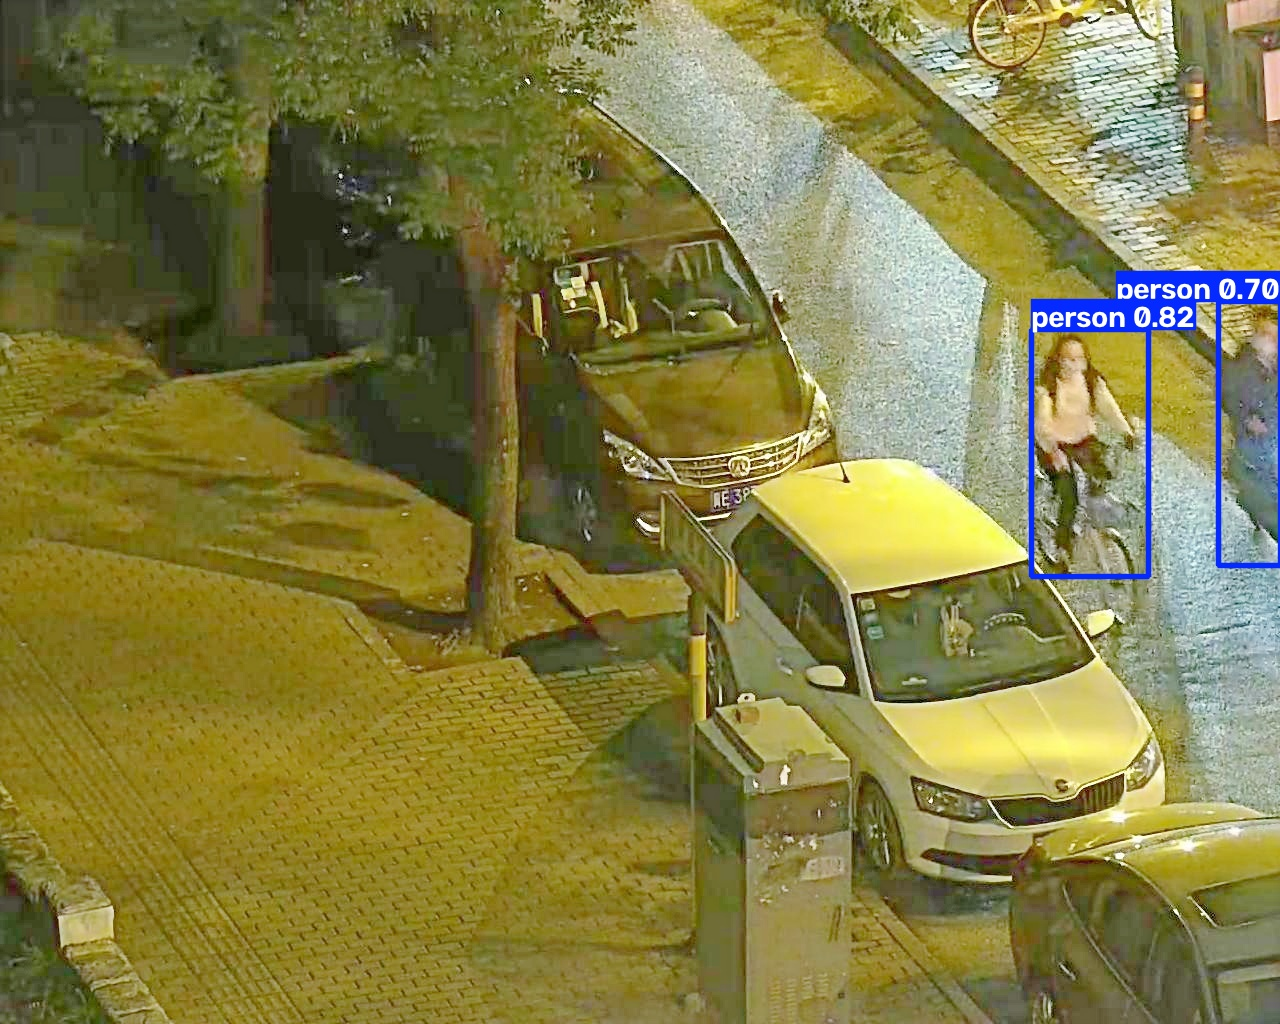

190002.jpg


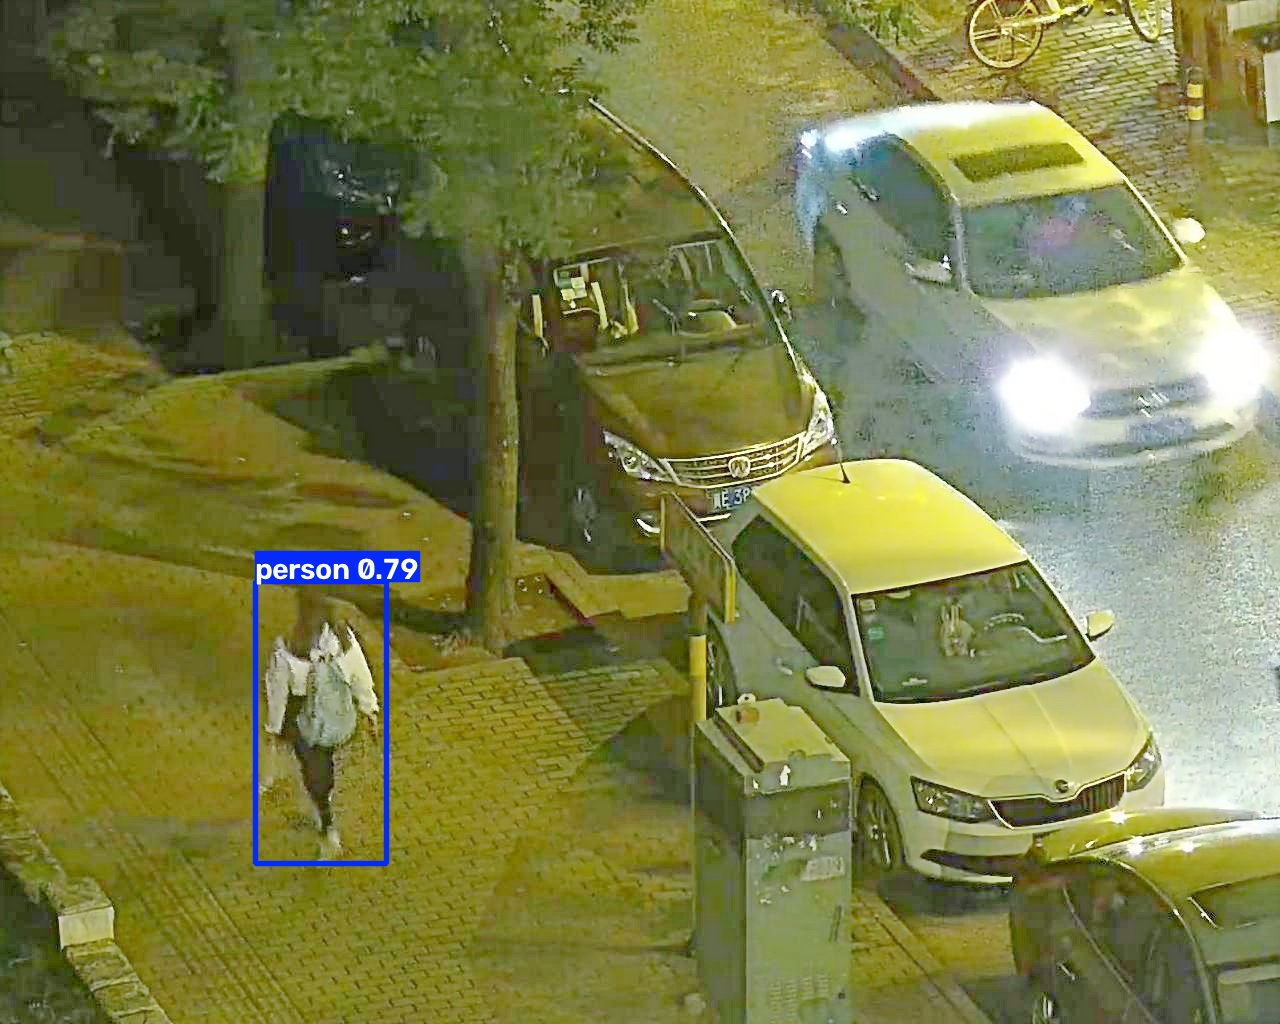

190003.jpg


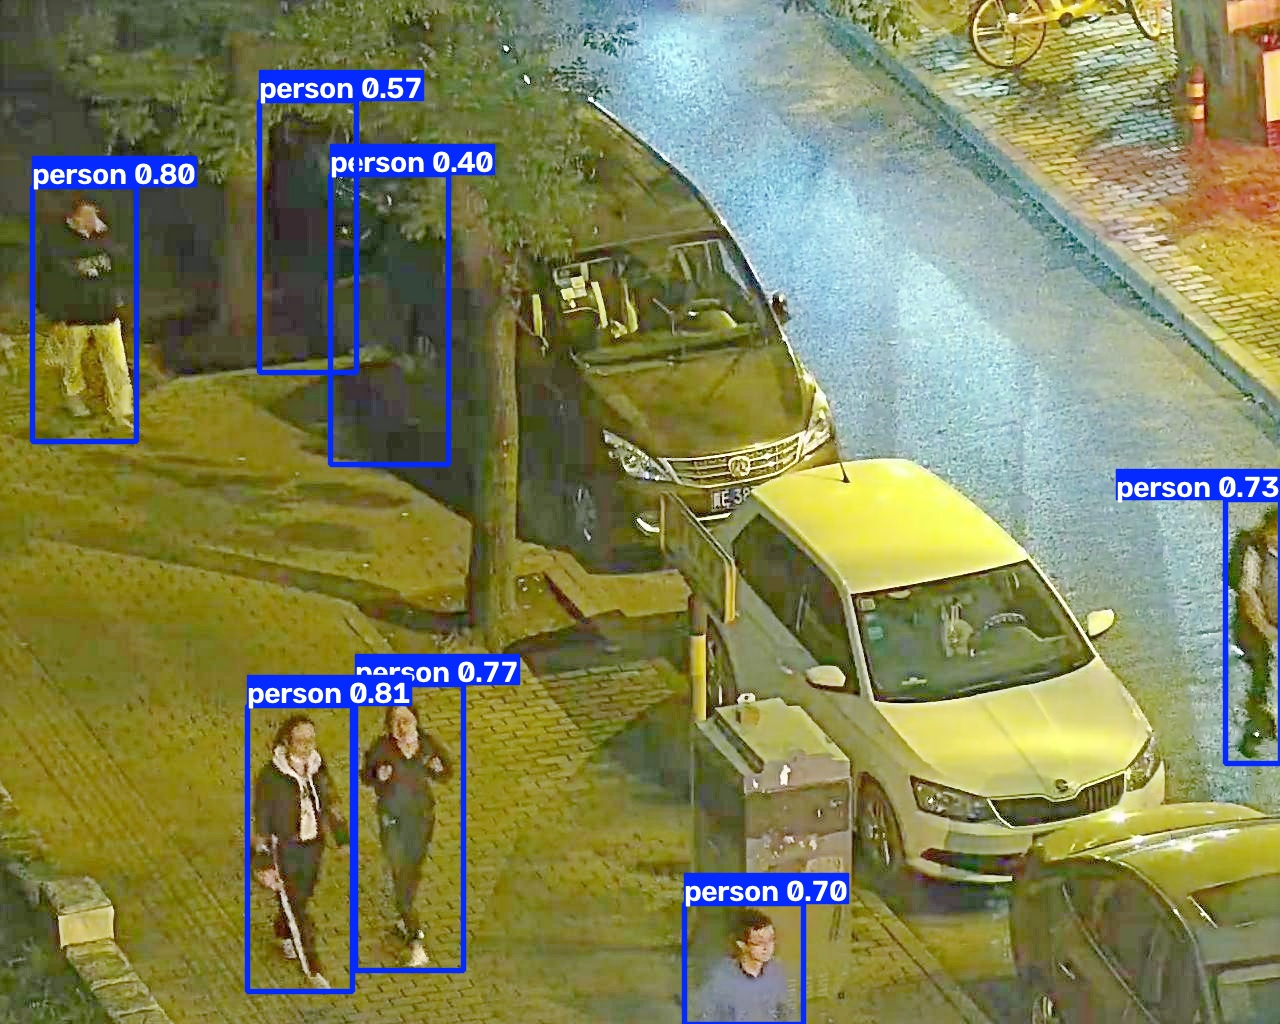

190004.jpg


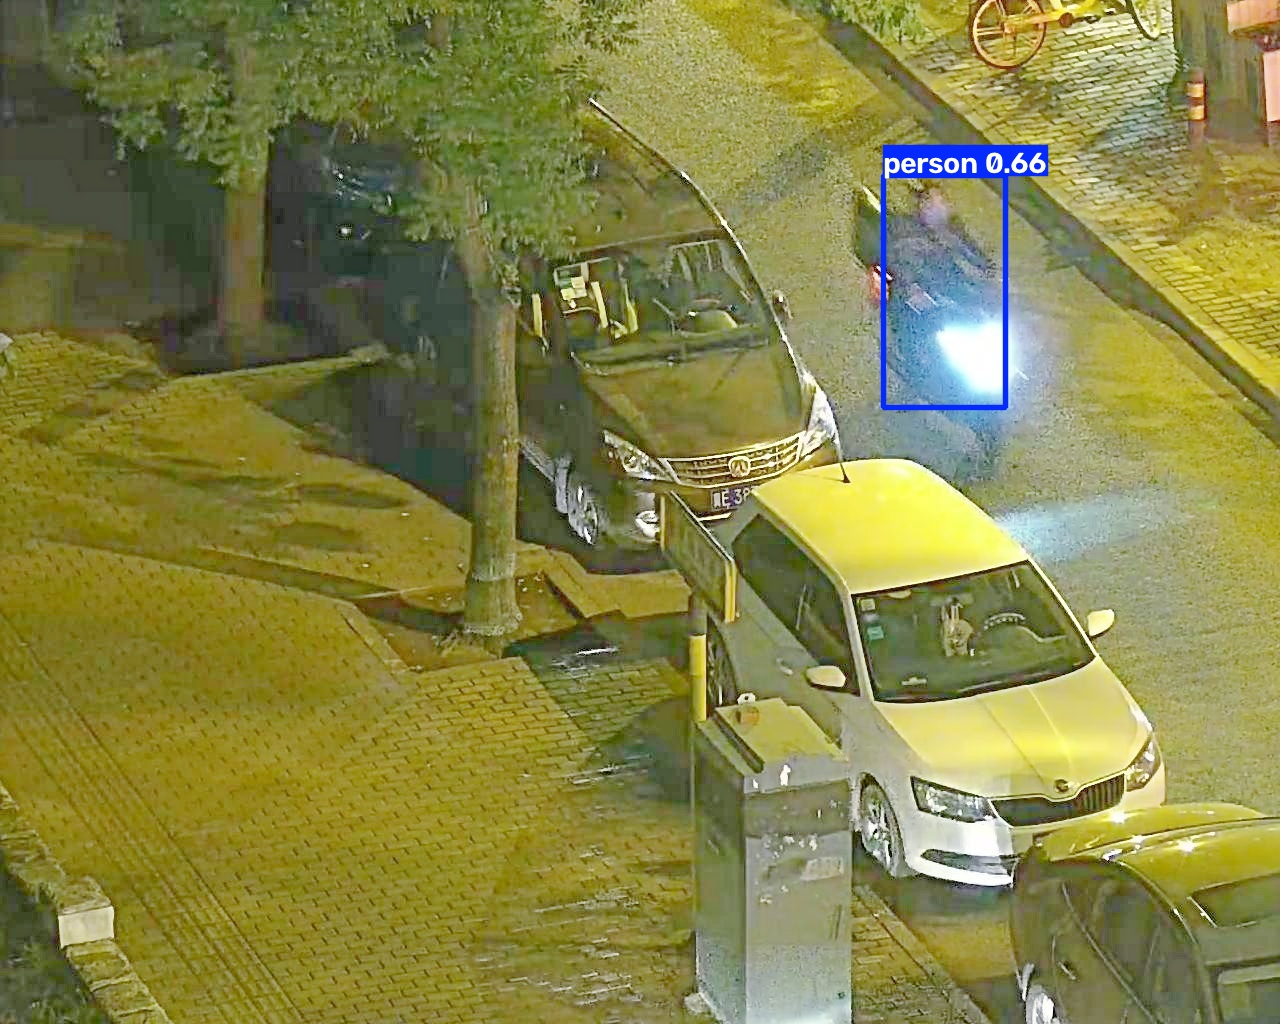

190005.jpg


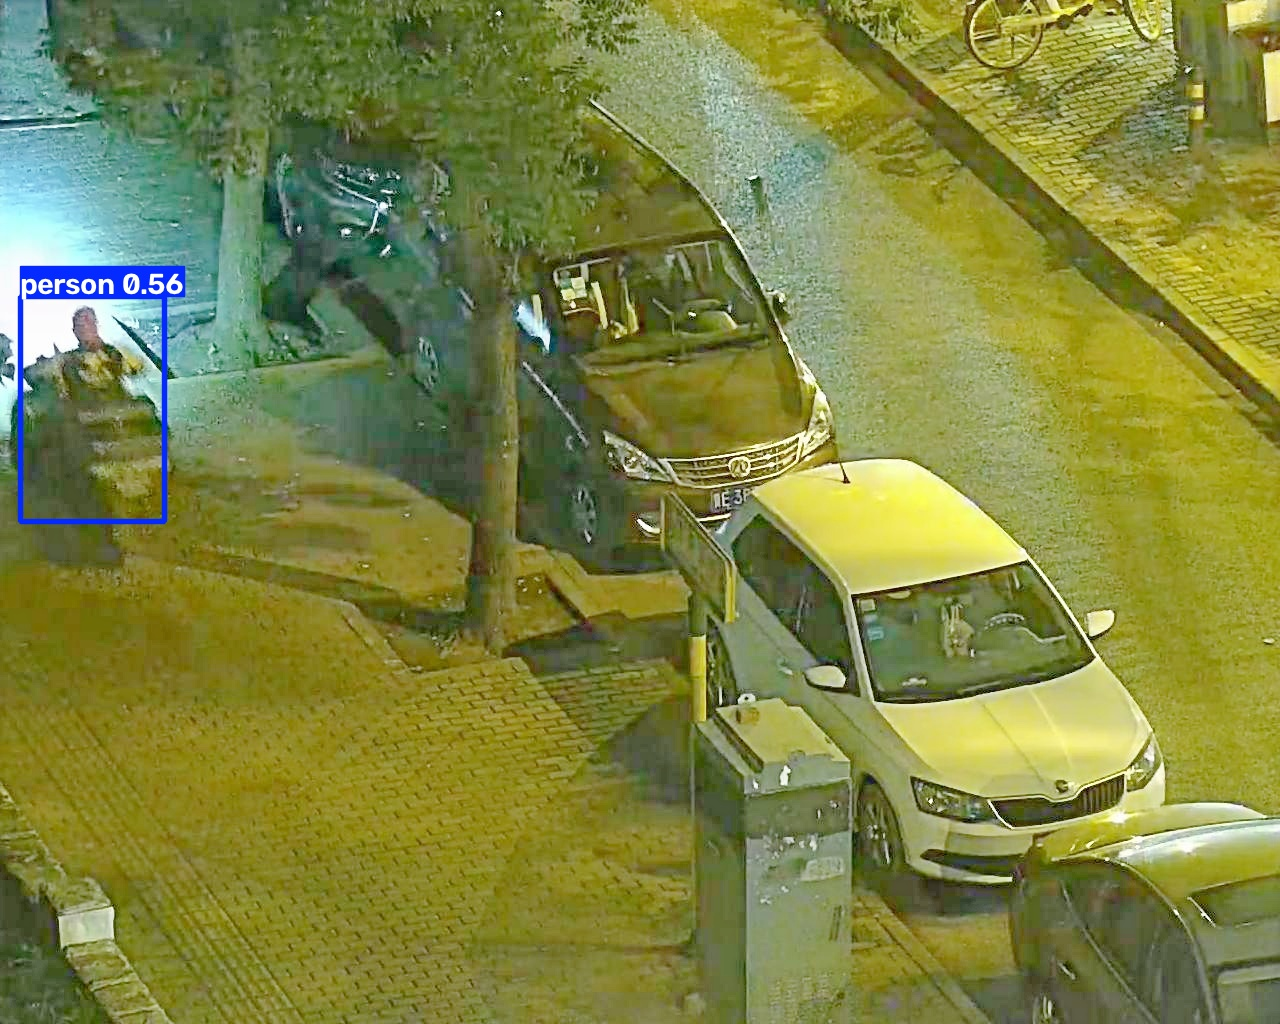

190006.jpg


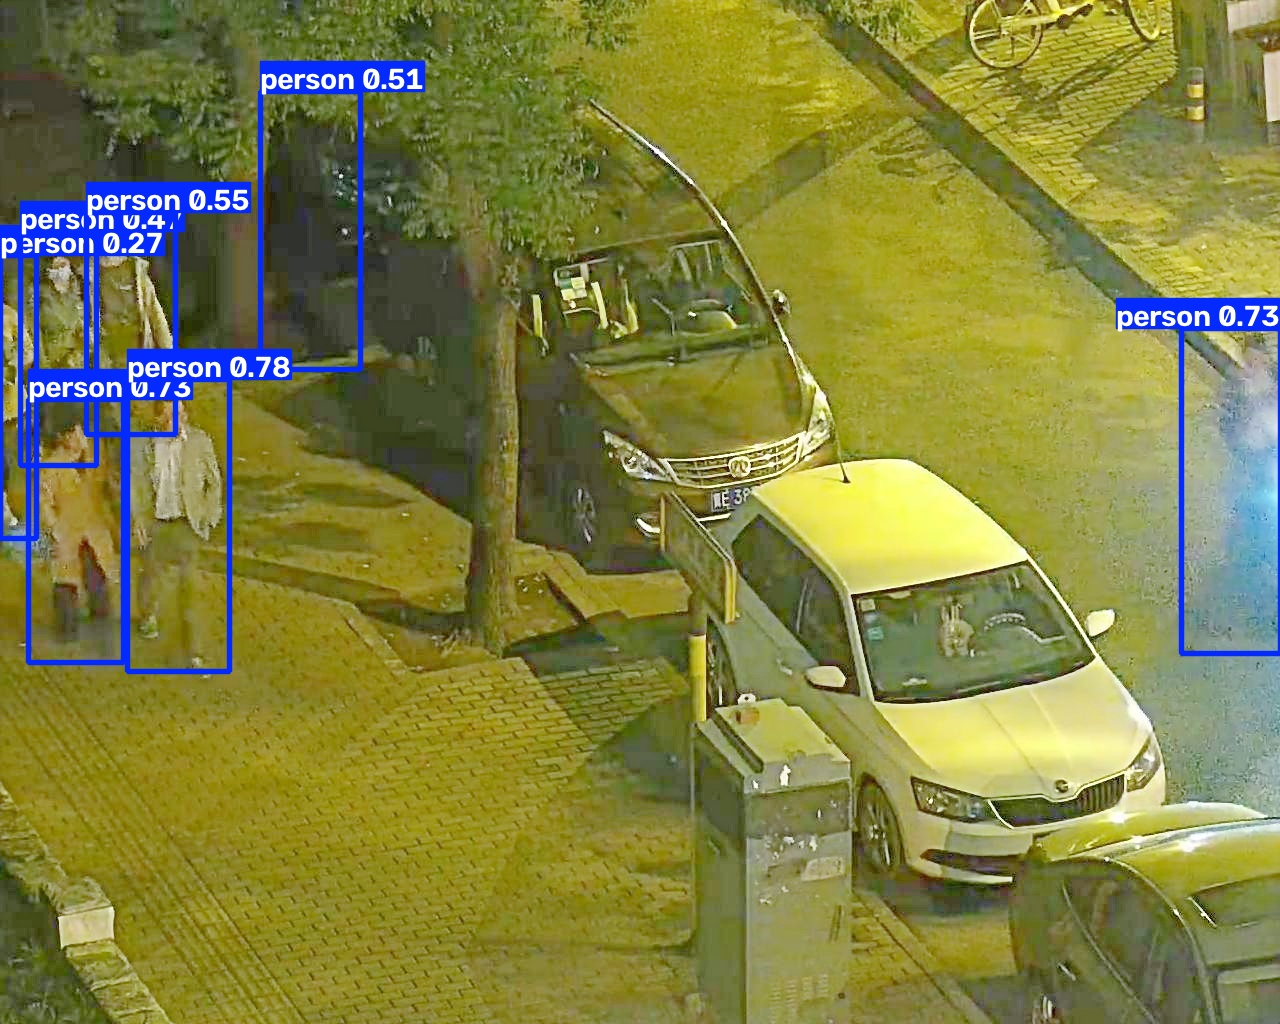

In [45]:
prediction_files = sorted(
    SAMPLE_PREDICTIONS_ROOT.glob("*.jpg")
)

print("Prediction images:", len(prediction_files))

for prediction_file in prediction_files[:6]:
    print(prediction_file.name)

    display(
        IPImage(
            filename=str(prediction_file)
        )
    )